# Model Testing Scaffold (Images -> Predictions -> Metrics)

This notebook is set up to:
- run each model on image folders (no video required),
- save DeepLabCut predictions as CSV,
- compare predictions to labeled truth CSV files when available,
- compute:
  - RMSE across predicted points,
  - number and percent of fully successful frames,
  - percent of correctly identified points across all frames.

It is safe to run now even before truth CSV files are added.

In [2]:
from __future__ import annotations

import math
import re
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [66]:
# ----------------------------
# User configuration
# ----------------------------
RUN_INFERENCE = False
RUN_EVALUATION = False
DISTANCE_THRESHOLD_PX = 8.0

BIRD_NAMES = ["DavidBowie", "Endive"]

NOTEBOOK_DIR = Path.cwd()
TESTING_ROOT = NOTEBOOK_DIR.parent
DEEPLABCUT_ROOT = TESTING_ROOT / "DeepLabCut"

# Optional: set this if your frame identifiers do not naturally align between
# prediction and truth files. Use same key format as normalize_frame_key output.
FRAME_MAP: dict[Any, Any] = {}

print(f"Testing root: {TESTING_ROOT}")
print(f"DeepLabCut root: {DEEPLABCUT_ROOT}")

Testing root: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing
DeepLabCut root: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut


In [67]:
@dataclass
class ModelEvalSetup:
    bird: str
    model_name: str
    config_path: Path
    image_folder: Path
    truth_csv: Path
    output_folder: Path


def discover_model_configs(bird_root: Path) -> list[Path]:
    testdata = bird_root / "ModelBuildExperiments"
    if not testdata.exists():
        return []

    configs = sorted(testdata.glob("Canari_combined_n*/**/config.yaml"))
    if configs:
        return configs

    # Fallback if naming changes later.
    return sorted(testdata.glob("**/config.yaml"))


def build_setups() -> list[ModelEvalSetup]:
    setups: list[ModelEvalSetup] = []

    for bird in BIRD_NAMES:
        bird_root = DEEPLABCUT_ROOT / bird
        image_folder = bird_root / "ExperimentEval" / "long_video_frames"
        truth_csv = bird_root / "ExperimentEval" / "long_video_labeled_points.csv"

        for cfg in discover_model_configs(bird_root):
            model_name = cfg.parent.name
            output_folder = bird_root / "ExperimentEval" / "predictions" / model_name
            setups.append(
                ModelEvalSetup(
                    bird=bird,
                    model_name=model_name,
                    config_path=cfg,
                    image_folder=image_folder,
                    truth_csv=truth_csv,
                    output_folder=output_folder,
                )
            )

    return setups


setups = build_setups()
print(f"Discovered {len(setups)} model setup(s).")
pd.DataFrame(
    {
        "bird": [s.bird for s in setups],
        "model_name": [s.model_name for s in setups],
        "config_exists": [s.config_path.exists() for s in setups],
        "image_folder": [str(s.image_folder) for s in setups],
        "truth_csv": [str(s.truth_csv) for s in setups],
    }
).head(20)

Discovered 11 model setup(s).


,bird,model_name,config_exists,image_folder,truth_csv
0,DavidBowie,Canari-Tyler-2026-04-22,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
1,DavidBowie,Canari-Tyler-2026-04-24,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
2,DavidBowie,Canari-Tyler-2026-04-22,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
3,DavidBowie,Canari-Tyler-2026-04-24,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
4,DavidBowie,Canari-Tyler-2026-04-22,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
5,DavidBowie,Canari-Tyler-2026-04-24,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
6,DavidBowie,Canari-Tyler-2026-04-22,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
7,Endive,Canari-Tyler-2026-04-08,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
8,Endive,Canari-Tyler-2026-04-08,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
9,Endive,Canari-Tyler-2026-04-08,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...


In [68]:
# Endive: find union of frames used for training, then list frames not used.

image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

ENDIVE_ROOT = DEEPLABCUT_ROOT / "Endive"
ENDIVE_TRAINING_DIR = ENDIVE_ROOT / "trainingdata" / "Endive_20251606_F32"


def extract_frame_number_from_stem(stem: str) -> int | None:
    # Example stem: Endive_20251606_F32_cam1_0521 -> frame 521
    match = re.search(r"(\d+)$", stem)
    if not match:
        return None
    return int(match.group(1))


endive_config_paths = discover_model_configs(ENDIVE_ROOT)
if not endive_config_paths:
    raise FileNotFoundError(f"No Endive model config files found under {ENDIVE_ROOT / 'TestData'}")

# Union of all frame IDs used by any Endive model.
endive_used_frames_union: set[int] = set()
per_model_frame_counts: list[dict[str, Any]] = []

for config_path in sorted(endive_config_paths):
    print(f"Processing Endive model config: {config_path}")
    labeled_dir = config_path.parent / "labeled-data"
    image_paths = [
        p for p in labeled_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in image_exts
    ]

    frame_ids = {
        frame_id
        for p in image_paths
        for frame_id in [extract_frame_number_from_stem(p.stem)]
        if frame_id is not None
    }

    endive_used_frames_union.update(frame_ids)
    per_model_frame_counts.append(
        {
            "model": config_path.parent.name,
            "n_unique_frames_used": len(frame_ids),
            "labeled_data_dir": str(labeled_dir),
        }
    )

# Determine all available frame IDs from Endive trainingdata CSV.
training_csvs = sorted(ENDIVE_TRAINING_DIR.glob("*.csv"))
if not training_csvs:
    raise FileNotFoundError(f"No CSV files found in {ENDIVE_TRAINING_DIR}")

endive_training_csv_path = training_csvs[0]
endive_training_df = pd.read_csv(endive_training_csv_path)

# CSV rows correspond to frames; use 1-based IDs to match image naming like ..._0001.
endive_all_training_frames = set(range(1, len(endive_training_df) + 1))

# Frames present in trainingdata but never used by any model's labeled-data.
endive_unused_training_frames = sorted(endive_all_training_frames - endive_used_frames_union)

# Also keep used-in-trainingdata intersection for sanity checks.
endive_used_training_frames = sorted(endive_all_training_frames & endive_used_frames_union)

print(f"Training CSV: {endive_training_csv_path}")
print(f"Total frames in trainingdata CSV: {len(endive_all_training_frames)}")
print(f"Union of used frames across Endive models: {len(endive_used_frames_union)}")
print(f"Used frames that are in trainingdata: {len(endive_used_training_frames)}")
print(f"Unused frames in trainingdata: {len(endive_unused_training_frames)}")

# Requested output list.
endive_unused_training_frames[:25], endive_unused_training_frames[-25:]


Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ModelBuildExperiments\Endive_n1400_T32\Canari-Tyler-2026-04-08\config.yaml
Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ModelBuildExperiments\Endive_n200_T32\Canari-Tyler-2026-04-08\config.yaml
Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ModelBuildExperiments\Endive_n400_T32\Canari-Tyler-2026-04-08\config.yaml
Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ModelBuildExperiments\Endive_n800_T32\Canari-Tyler-2026-04-08\config.yaml
Training CSV: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\trainingdata\Endive_20251606_F32\2025_16_06_Maya_F32_no_filter_trimmed.csv
Total frames in trainingda

([2,
  3,
  4,
  5,
  7,
  9,
  11,
  12,
  14,
  15,
  23,
  25,
  26,
  27,
  30,
  32,
  33,
  34,
  38,
  39,
  40,
  42,
  48,
  51,
  52],
 [3650,
  3651,
  3655,
  3656,
  3658,
  3659,
  3661,
  3662,
  3663,
  3664,
  3667,
  3668,
  3670,
  3671,
  3674,
  3676,
  3678,
  3679,
  3680,
  3682,
  3683,
  3686,
  3688,
  3689,
  3690])

## Endive Model Batch Test on Unused Frames

This section will:
1. Build subset AVI videos containing only `endive_unused_training_frames`.
2. Create one ExperimentEval output folder per Endive model.
3. Run DeepLabCut on each subset video and save CSV point predictions.
4. Create labeled AVI videos for quick visual QA.

Set `RUN_ENDIVE_UNUSED_FRAME_BATCH = True` to execute.

In [70]:
# ----------------------------
# Endive unused-frame batch inference
# ----------------------------
RUN_ENDIVE_UNUSED_FRAME_BATCH = True

ENDIVE_EXPERIMENT_EVAL_DIR = ENDIVE_ROOT / "ExperimentEval"
# Keep paths short on Windows to avoid MAX_PATH issues with DLC filenames.
ENDIVE_BATCH_ROOT = ENDIVE_EXPERIMENT_EVAL_DIR / "UFBatch"

# Source videos from Endive trainingdata. Both cam1 and cam2 are supported.
ENDIVE_SOURCE_VIDEOS = sorted(ENDIVE_TRAINING_DIR.glob("*.avi"))


def as_posix_str(path_like: Any) -> str:
    return Path(path_like).as_posix()


def build_subset_video_from_frame_ids(
    src_video: Path,
    dst_video: Path,
    frame_ids_1_based: list[int],
) -> dict[str, Any]:
    try:
        import cv2
    except Exception as exc:
        raise ImportError("OpenCV (cv2) is required to build subset videos.") from exc

    frame_set_0_based = sorted({max(0, f - 1) for f in frame_ids_1_based})
    if not frame_set_0_based:
        raise ValueError("No frame IDs provided for subset video creation.")

    cap = cv2.VideoCapture(str(src_video))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open source video: {src_video}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 500.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*"MJPG")
    dst_video.parent.mkdir(parents=True, exist_ok=True)
    writer = cv2.VideoWriter(str(dst_video), fourcc, fps, (width, height))

    written = 0
    missing = 0

    try:
        for frame_idx in frame_set_0_based:
            if frame_idx >= total_frames:
                missing += 1
                continue

            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ok, frame = cap.read()
            if not ok:
                missing += 1
                continue

            if frame.shape[1] != width or frame.shape[0] != height:
                frame = cv2.resize(frame, (width, height))

            writer.write(frame)
            written += 1
    finally:
        writer.release()
        cap.release()

    return {
        "src_video": str(src_video),
        "dst_video": str(dst_video),
        "requested_frames": len(frame_set_0_based),
        "written_frames": written,
        "missing_frames": missing,
        "fps": fps,
        "width": width,
        "height": height,
    }


def ensure_meta_pickles_for_videos(
    output_dir: Path,
    videos: list[Path],
) -> dict[str, Any]:
    """Ensure *_meta.pickle exists for each analyzed video when possible."""
    created = 0
    available_videos: list[Path] = []

    for v in videos:
        stem = v.stem
        meta_pickles = sorted(output_dir.glob(f"{stem}DLC*_meta.pickle"))

        if not meta_pickles:
            full_pickles = sorted(output_dir.glob(f"{stem}DLC*_full.pickle"))
            for full in full_pickles:
                meta = full.with_name(full.name.replace("_full.pickle", "_meta.pickle"))
                if not meta.exists():
                    meta.write_bytes(full.read_bytes())
                    created += 1
            meta_pickles = sorted(output_dir.glob(f"{stem}DLC*_meta.pickle"))

        if meta_pickles:
            available_videos.append(v)

    return {
        "meta_created": created,
        "videos_with_meta": available_videos,
        "videos_missing_meta": [v for v in videos if v not in available_videos],
    }


if not ENDIVE_SOURCE_VIDEOS:
    raise FileNotFoundError(f"No source .avi files found in {ENDIVE_TRAINING_DIR}")

if "endive_unused_training_frames" not in globals():
    raise RuntimeError(
        "`endive_unused_training_frames` was not found. Run Cell 7 first to generate it."
    )

# Build subset (unlabeled) AVI once, then reuse for all models.
subset_video_dir = ENDIVE_BATCH_ROOT / "sv"
subset_build_log: list[dict[str, Any]] = []
subset_videos: list[Path] = []

for src_video in ENDIVE_SOURCE_VIDEOS:
    cam_tag = "cam2" if "cam2" in src_video.stem.lower() else "cam1"
    subset_name = f"uf_{cam_tag}.avi"
    subset_path = subset_video_dir / subset_name
    subset_videos.append(subset_path)

    if RUN_ENDIVE_UNUSED_FRAME_BATCH:
        info = build_subset_video_from_frame_ids(
            src_video=src_video,
            dst_video=subset_path,
            frame_ids_1_based=endive_unused_training_frames,
        )
        subset_build_log.append(info)

if RUN_ENDIVE_UNUSED_FRAME_BATCH and subset_build_log:
    display(pd.DataFrame(subset_build_log))

# Run all Endive models and write outputs to per-model folders.
# Note: we reference shared subset_videos directly and do not copy unlabeled videos into each model folder.
endive_model_configs = sorted(discover_model_configs(ENDIVE_ROOT))
batch_rows: list[dict[str, Any]] = []

if RUN_ENDIVE_UNUSED_FRAME_BATCH:
    import deeplabcut

for config_path in endive_model_configs:
    n_folder = config_path.parent.parent.name  # e.g., Canari_combined_n200
    n_token = n_folder.replace("Canari_combined_", "")  # e.g., n200
    model_slug = n_token
    model_out_dir = ENDIVE_BATCH_ROOT / model_slug
    model_out_dir.mkdir(parents=True, exist_ok=True)

    row: dict[str, Any] = {
        "model": model_slug,
        "config": str(config_path),
        "output_dir": str(model_out_dir),
        "n_subset_videos": len(subset_videos),
        "status": "ready" if not RUN_ENDIVE_UNUSED_FRAME_BATCH else "running",
        "error": None,
    }

    try:
        if RUN_ENDIVE_UNUSED_FRAME_BATCH:
            missing_subset = [v for v in subset_videos if not v.exists()]
            if missing_subset:
                raise FileNotFoundError(f"Subset videos missing: {missing_subset}")

            deeplabcut.analyze_videos(
                config=as_posix_str(config_path),
                videos=[as_posix_str(v) for v in subset_videos],
                destfolder=as_posix_str(model_out_dir),
                videotype=".avi",
                save_as_csv=True,
            )

            meta_info = ensure_meta_pickles_for_videos(model_out_dir, subset_videos)
            videos_for_labeling = meta_info["videos_with_meta"]
            row["meta_created"] = int(meta_info["meta_created"])
            row["videos_missing_meta"] = len(meta_info["videos_missing_meta"])

            if videos_for_labeling:
                deeplabcut.create_labeled_video(
                    config=as_posix_str(config_path),
                    videos=[as_posix_str(v) for v in videos_for_labeling],
                    destfolder=as_posix_str(model_out_dir),
                    videotype=".avi",
                )
            else:
                raise FileNotFoundError(
                    "No *_meta.pickle found after analysis for any subset video. "
                    "Labeled video generation skipped."
                )

            # Also generate DLC trajectory plots for this model output.
            deeplabcut.plot_trajectories(
                as_posix_str(config_path),
                [as_posix_str(v) for v in subset_videos],
                videotype=".avi",
                destfolder=as_posix_str(model_out_dir),
            )

            row["status"] = "done"

            csv_files = sorted(model_out_dir.glob("*DLC*.csv"))
            labeled_videos = sorted(model_out_dir.glob("*labeled*.*"))
            traj_plots = sorted(model_out_dir.glob("*plot-poses*"))

            row["n_csv_files"] = len(csv_files)
            row["n_labeled_videos"] = len(labeled_videos)
            row["n_trajectory_plot_dirs"] = len(traj_plots)
    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)

    batch_rows.append(row)

batch_df = pd.DataFrame(batch_rows)
print(f"Batch root: {ENDIVE_BATCH_ROOT}")
print(f"RUN_ENDIVE_UNUSED_FRAME_BATCH = {RUN_ENDIVE_UNUSED_FRAME_BATCH}")
batch_df

KeyboardInterrupt: 

## Basic Training Stats
#### Generated by the model training process itself

In [82]:
import glob
#birds = ["DavidBowie", "Endive"]
birds = ["DavidBowie", "Endive"]
def model_sort_key(name: str):
    m = re.search(r"(\d+)$", name)
    return int(m.group(1)) if m else float("inf")
modelnums = [200, 400, 800, 1400]
trial_numbers = [15, 17, 32]

# Discover model names from both birds, then keep first 4 in numeric order
all_models_dict = {}
all_models_df = pd.DataFrame()
for bird in birds:
    for modelNum in modelnums:
        for trial in trial_numbers:
            base_path = (DEEPLABCUT_ROOT / bird  / "ModelBuildExperiments" / f"{bird}_n{modelNum}_T{trial}"
            )
            if not base_path.exists():
                print(f"Base path does not exist: {base_path}")
                continue
            print(base_path)
            paths = list(
                base_path.glob(
                "Canari-Tyler*/dlc-models-pytorch/iteration-0/*-trainset95shuffle1/train/learning_stats.csv"
                )
            )

            model_training_stats = pd.read_csv(paths[0])
            if not model_training_stats.empty:
                model_training_stats['Model'] = f"n{modelNum}"
                model_training_stats['Bird'] = bird
                model_training_stats['Trial'] = trial
                all_models_dict[f"{bird}n{modelNum}T{trial}"] = model_training_stats
                all_models_df = pd.concat([all_models_df, model_training_stats], ignore_index=True)

all_models_df.head()


c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T17
Base path does not exist: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T32
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n400_T15
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n400_T17
Base path does not exist: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n400_T32
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\Da

,step,losses/eval.bodypart_heatmap,losses/eval.bodypart_locref,losses/eval.bodypart_total_loss,losses/eval.total_loss,losses/train.bodypart_heatmap,losses/train.bodypart_locref,losses/train.bodypart_total_loss,losses/train.total_loss,metrics/test.mAP,metrics/test.mAR,metrics/test.rmse,metrics/test.rmse_pcutoff,Model,Bird,Trial
0,1,NaN,NaN,NaN,NaN,0.001683,0.348663,0.009558,0.009558,NaN,NaN,NaN,NaN,n200,DavidBowie,15
1,2,NaN,NaN,NaN,NaN,0.000841,0.099795,0.002915,0.002915,NaN,NaN,NaN,NaN,n200,DavidBowie,15
2,3,NaN,NaN,NaN,NaN,0.000522,0.060624,0.001777,0.001777,NaN,NaN,NaN,NaN,n200,DavidBowie,15
3,4,NaN,NaN,NaN,NaN,0.000449,0.053828,0.001570,0.001570,NaN,NaN,NaN,NaN,n200,DavidBowie,15
4,5,NaN,NaN,NaN,NaN,0.000325,0.040888,0.001185,0.001185,NaN,NaN,NaN,NaN,n200,DavidBowie,15


In [98]:
all_models_df.WRITE_TO_CSV = True
if all_models_df.WRITE_TO_CSV:
    output_csv_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL\all_model_training_stats.csv"
    all_models_df.to_csv(output_csv_path, index=False)
    print(f"All model training stats written to: {output_csv_path}")

All model training stats written to: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL\all_model_training_stats.csv


In [ ]:
# make widget to filter between loss types
from ipywidgets import widgets
from ipywidgets import interactive
def plot_loss(loss_type, bird, trial):
    plt.figure(figsize=(12, 8))    
    sns.lineplot(data=all_models_df[(all_models_df['Bird'].isin(bird)) & (all_models_df['Trial'].isin(trial))], x='step', y=loss_type, hue='Model', style='Bird', markers=True)

    plt.title(f'Training Loss Curves for {bird} - {loss_type}')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.legend(title='Model')
    plt.show()
loss_types = ["losses/eval.bodypart_heatmap", "losses/eval.bodypart_locref", "losses/eval.bodypart_total_loss", "losses/eval.total_loss", "losses/train.bodypart_heatmap", "losses/train.bodypart_locref", "losses/train.bodypart_total_loss", "losses/train.total_loss"] 
trial_options = [15, 17, 32]
loss_type_widget = widgets.Dropdown(options=loss_types, description='Loss Type:')
bird_widget = widgets.SelectMultiple(options=birds, description='Bird:')   
trial_widget = widgets.SelectMultiple(options=trial_options, description='Trial:')
interactive_plot = interactive(plot_loss, loss_type=loss_type_widget, bird=bird_widget, trial=trial_widget)
display(interactive_plot)


interactive(children=(Dropdown(description='Loss Type:', options=('losses/eval.bodypart_heatmap', 'losses/eval…

In [ ]:
# now we compare test metrics in the same manner
test_metrics_list = ["metrics/test.mAP", "metrics/test.mAR", "metrics/test.rmse", "metrics/test.rmse_pcutoff"]
interactive_plot = interactive(plot_loss, loss_type=test_metrics_list, bird=bird_widget, trial=trial_widget)
display(interactive_plot)

interactive(children=(Dropdown(description='loss_type', options=('metrics/test.mAP', 'metrics/test.mAR', 'metr…

In [26]:
# ----------------------------
# Helpers
# ----------------------------
def infer_camera_from_name(name: str) -> str:
    """Infer camera label from a DLC output filename.

    Args:
        name: File name or path string containing camera hints.

    Returns:
        "cam2" if the text contains "cam2" (case-insensitive), else "cam1".
    """
    low = name.lower()
    if "cam2" in low:
        return "cam2"
    return "cam1"


def truth_csv_to_long(truth_csv_path: Path) -> pd.DataFrame:
    """Convert wide-format truth CSV into long-format point records.

    Expected columns follow the pattern <bodypart>_cam<1|2>_<X|Y>.

    Args:
        truth_csv_path: Path to the truth CSV file.

    Returns:
        DataFrame with columns: frame_id, bodypart, camera, x_true, y_true.

    Raises:
        ValueError: If no valid truth columns are detected.
    """
    truth_df = pd.read_csv(truth_csv_path)

    rows = []
    for col in truth_df.columns:
        m = re.match(r"(?P<bodypart>.+)_cam(?P<cam>[12])_(?P<coord>[XY])$", col)
        if m is None:
            continue
        rows.append((m.group("bodypart"), f"cam{m.group('cam')}", m.group("coord").lower(), col))

    if not rows:
        raise ValueError("Could not parse truth CSV columns with pattern <bodypart>_cam<1|2>_<X|Y>.")

    meta = pd.DataFrame(rows, columns=["bodypart", "camera", "coord", "column"])
    xmeta = meta[meta["coord"] == "x"].rename(columns={"column": "xcol"})
    ymeta = meta[meta["coord"] == "y"].rename(columns={"column": "ycol"})
    pairs = xmeta.merge(ymeta[["bodypart", "camera", "ycol"]], on=["bodypart", "camera"], how="inner")

    long_parts = []
    frame_ids = np.arange(1, len(truth_df) + 1)  # 1-based frame ids

    for _, r in pairs.iterrows():
        temp = pd.DataFrame(
            {
                "frame_id": frame_ids,
                "bodypart": r["bodypart"],
                "camera": r["camera"],
                "x_true": pd.to_numeric(truth_df[r["xcol"]], errors="coerce"),
                "y_true": pd.to_numeric(truth_df[r["ycol"]], errors="coerce"),
            }
        )
        long_parts.append(temp)

    out = pd.concat(long_parts, ignore_index=True)
    return out


def prediction_csv_to_long(pred_csv_path: Path, frame_id_lookup: list[int], fresh_vid: bool = False) -> pd.DataFrame:
    """Convert a DLC prediction CSV to long format and map subset indices.

    Args:
        pred_csv_path: Path to DLC CSV with MultiIndex columns [scorer, bodypart, coord].
        frame_id_lookup: Index-to-frame mapping from subset order to original 1-based frame ids.

    Returns:
        DataFrame with columns: frame_id, bodypart, camera, x_pred, y_pred, likelihood.

    Raises:
        ValueError: If no usable x/y columns are found in the prediction CSV.
    """
    wide = pd.read_csv(pred_csv_path, header=[0, 1, 2], index_col=0)
    camera = infer_camera_from_name(pred_csv_path.name)

    bp_level = wide.columns.get_level_values(1)
    coord_level = wide.columns.get_level_values(2).astype(str).str.lower()
    bodyparts = pd.Index(bp_level).unique()

    long_parts = []
    for bp in bodyparts:
        bp_cols = wide.xs(bp, axis=1, level=1, drop_level=False)
        coords = bp_cols.columns.get_level_values(2).astype(str).str.lower().tolist()
        if "x" not in coords or "y" not in coords:
            continue

        xcol = bp_cols.columns[coords.index("x")]
        ycol = bp_cols.columns[coords.index("y")]

        if "likelihood" in coords:
            lcol = bp_cols.columns[coords.index("likelihood")]
            like = pd.to_numeric(bp_cols[lcol], errors="coerce").to_numpy(dtype=float)
        else:
            like = np.full(shape=(bp_cols.shape[0],), fill_value=np.nan)

        # Map subset frame index (0..N-1) back to original 1-based frame id.
        subset_idx = pd.to_numeric(pd.Index(wide.index), errors="coerce").astype("Int64")
        
        if fresh_vid:
            frame_ids = subset_idx
        else:
            frame_ids = [frame_id_lookup[i] if pd.notna(i) and 0 <= int(i) < len(frame_id_lookup) else np.nan for i in subset_idx]
        
        temp = pd.DataFrame(
            {
                "frame_id": frame_ids,
                "bodypart": str(bp),
                "camera": camera,
                "x_pred": pd.to_numeric(bp_cols[xcol], errors="coerce").to_numpy(dtype=float),
                "y_pred": pd.to_numeric(bp_cols[ycol], errors="coerce").to_numpy(dtype=float),
                "likelihood": like,
            }
        )
        long_parts.append(temp)

    if not long_parts:
        raise ValueError(f"No usable x/y prediction columns in {pred_csv_path}")

    return pd.concat(long_parts, ignore_index=True)


In [190]:
# Endive model-vs-truth comparison on unused-frame subset

#### Figure out threshold for good vs bad predictions. Options:
# - RMSE-based: compute RMSE across all predictions for a model, then use that as a threshold for "good" vs "bad" predictions. This is relative to each model's overall performance.
# - Fixed threshold: use a fixed pixel distance (e.g., 8px) as the cutoff for good vs bad predictions. This is absolute and consistent across models.
# what else...


# ----------------------------
# Configuration
# ----------------------------
THRESHOLD_MODE = "rmse"   # "rmse" or "fixed"
FIXED_THRESHOLD_PX = 8.0   # used only when THRESHOLD_MODE == "fixed"
DISPLACEMENT_SCATTER_MAX_POINTS = 50000
POINT_ERROR_SCATTER_MAX_POINTS = 50000



# ----------------------------
# Data loading
# ----------------------------
if "ENDIVE_BATCH_ROOT" not in globals():
    raise RuntimeError("Run the Endive batch cell first so ENDIVE_BATCH_ROOT is defined.")

if "endive_unused_training_frames" not in globals():
    raise RuntimeError("Run Cell 7 first so endive_unused_training_frames exists.")

frame_id_lookup = sorted(set(endive_unused_training_frames))

if "endive_training_csv_path" in globals():
    truth_csv_path = Path(endive_training_csv_path)
else:
    truth_csvs = sorted((ENDIVE_ROOT / "trainingdata" / "Endive_20251606_F32").glob("*.csv"))
    if not truth_csvs:
        raise FileNotFoundError("No Endive training truth CSV found.")
    truth_csv_path = truth_csvs[0]

truth_long = truth_csv_to_long(truth_csv_path)

model_dirs = sorted([p for p in ENDIVE_BATCH_ROOT.iterdir() if p.is_dir() and p.name.startswith("n")])

summary_rows = []
all_displacement_rows = []
all_error_rows = []

for model_dir in model_dirs:
    pred_csvs = sorted(model_dir.glob("*DLC*.csv"))
    if not pred_csvs:
        continue

    pred_long_parts = [prediction_csv_to_long(p, frame_id_lookup) for p in pred_csvs]
    pred_long = pd.concat(pred_long_parts, ignore_index=True)

    merged = pred_long.merge(
        truth_long,
        on=["frame_id", "bodypart", "camera"],
        how="inner",
    )

    merged = merged.dropna(subset=["frame_id", "x_pred", "y_pred", "x_true", "y_true"]).copy()
    if merged.empty:
        continue

    merged["distance_px"] = np.sqrt((merged["x_pred"] - merged["x_true"]) ** 2 + (merged["y_pred"] - merged["y_true"]) ** 2)

    error_rows = merged[["camera", "bodypart", "frame_id", "distance_px", "likelihood"]].copy()
    error_rows["model"] = model_dir.name
    error_rows['train_trial'] = 32
    error_rows['eval_trial'] = 32
    error_rows['pair'] = "Train32_Eval32"
    error_rows = error_rows[["model", "camera", "bodypart", "frame_id", "distance_px", "likelihood", "train_trial", "eval_trial", "pair"]]
    all_error_rows.append(error_rows)

    rmse = float(np.sqrt(np.mean(np.square(merged["distance_px"]))))
    threshold_px = rmse if THRESHOLD_MODE == "rmse" else float(FIXED_THRESHOLD_PX)

    merged["within_threshold"] = merged["distance_px"] <= FIXED_THRESHOLD_PX

    # Percent points within threshold
    pct_points = 100.0 * float(merged["within_threshold"].mean())

    # Percent frames where all predicted points are within threshold
    expected_per_frame = pred_long[["camera", "bodypart"]].drop_duplicates().shape[0]

    frame_stats = (
        merged.groupby("frame_id", as_index=False)
        .agg(
            n_points=("within_threshold", "size"),
            all_within=("within_threshold", "all"),
        )
    )
    frame_stats["frame_pass"] = frame_stats["all_within"] & (frame_stats["n_points"] == expected_per_frame)
    pct_frames = 100.0 * float(frame_stats["frame_pass"].mean())

    mean_likelihood = float(np.nanmean(merged["likelihood"])) if "likelihood" in merged.columns else np.nan

    summary_rows.append(
        {
            "model": model_dir.name,
            "rmse_px": rmse,
            "threshold_px": threshold_px,
            "percent_frames_all_points_within_threshold": pct_frames,
            "percent_points_within_threshold": pct_points,
            "mean_likelihood": mean_likelihood,
            "n_points": int(merged.shape[0]),
        }
    )

    # Euclidean displacement from frame t-1 to t and likelihood
    disp = merged.sort_values(["camera", "bodypart", "frame_id"]).copy()
    disp["dx"] = disp.groupby(["camera", "bodypart"])["x_pred"].diff()
    disp["dy"] = disp.groupby(["camera", "bodypart"])["y_pred"].diff()
    disp["euclidean_displacement_t-1_to_t"] = np.sqrt(disp["dx"] ** 2 + disp["dy"] ** 2)
    disp = disp.dropna(subset=["euclidean_displacement_t-1_to_t"])

    if not disp.empty:
        disp["model"] = model_dir.name
        disp = disp[["model", "camera", "bodypart", "frame_id", "euclidean_displacement_t-1_to_t", "likelihood"]]
        all_displacement_rows.append(disp)

summary_df = pd.DataFrame(summary_rows).sort_values("model").reset_index(drop=True)
if summary_df.empty:
    raise RuntimeError("No comparable prediction CSV data found in model output folders.")
summary_df["train_trial"] = 32
summary_df["eval_trial"] = 32
summary_df['pair'] = f"Train32_Eval32"
summary_df['model'] = summary_df['model'].apply(lambda x: f"Endive_{x}_T32")
display(summary_df)
error_df = pd.concat(all_error_rows, ignore_index=True)
error_df['model'] = error_df['model'].apply(lambda x: f"Endive_{x}_T32")
print(f"Total points compared across all models: {len(error_df)}")


write_summary_csv = True
if write_summary_csv:
    summary_csv_path = ENDIVE_BATCH_ROOT / "end_WithinTrial_summary_TrainTest32.csv"
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"Summary metrics written to: {summary_csv_path}")
    errors_csv_path = ENDIVE_BATCH_ROOT / "end_WithinTrial_errors_TrainTest32.csv"
    error_df.to_csv(errors_csv_path, index=False)
    print(f"All point errors written to: {errors_csv_path}")
    


,model,rmse_px,threshold_px,percent_frames_all_points_within_threshold,percent_points_within_threshold,mean_likelihood,n_points,train_trial,eval_trial,pair
0,Endive_n1400_T32,0.838132,0.838132,99.475983,99.987263,0.954448,109920,32,32,Train32_Eval32
1,Endive_n200_T32,1.174236,1.174236,97.947598,99.836245,0.957074,109920,32,32,Train32_Eval32
2,Endive_n400_T32,0.897349,0.897349,99.082969,99.930859,0.948333,109920,32,32,Train32_Eval32
3,Endive_n800_T32,0.822235,0.822235,99.519651,99.977256,0.956299,109920,32,32,Train32_Eval32


Total points compared across all models: 439680
Summary metrics written to: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\end_WithinTrial_summary_TrainTest32.csv
All point errors written to: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\end_WithinTrial_errors_TrainTest32.csv


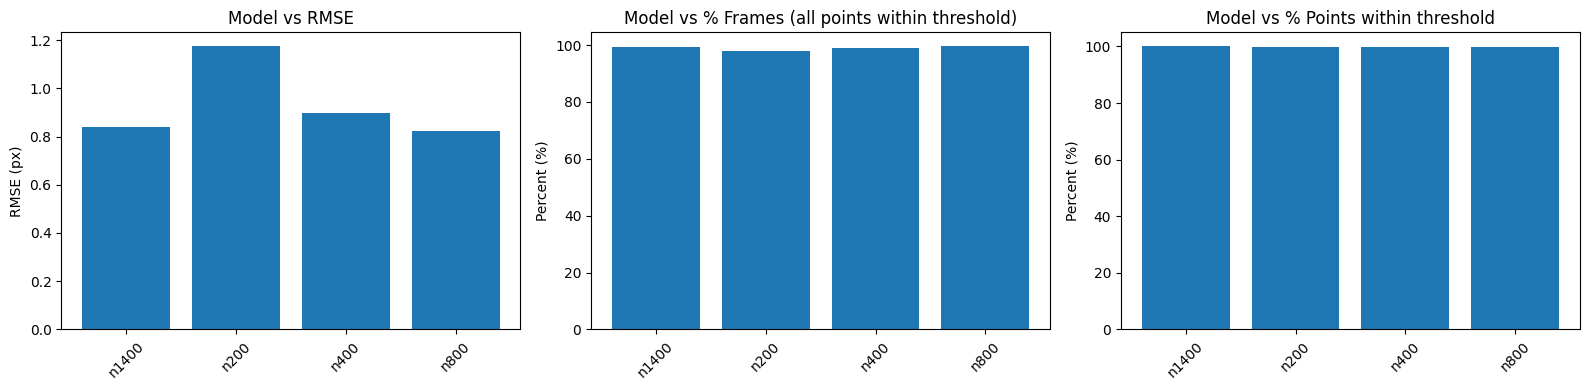

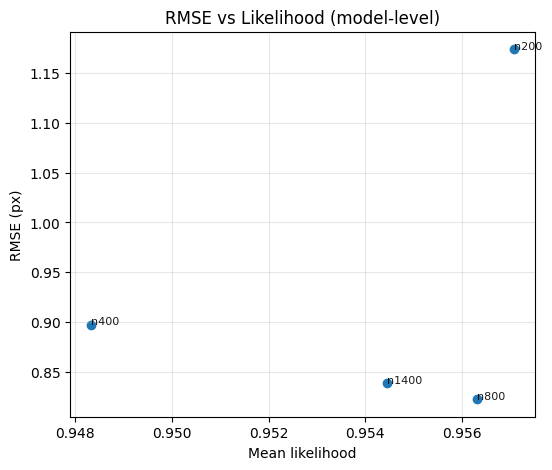

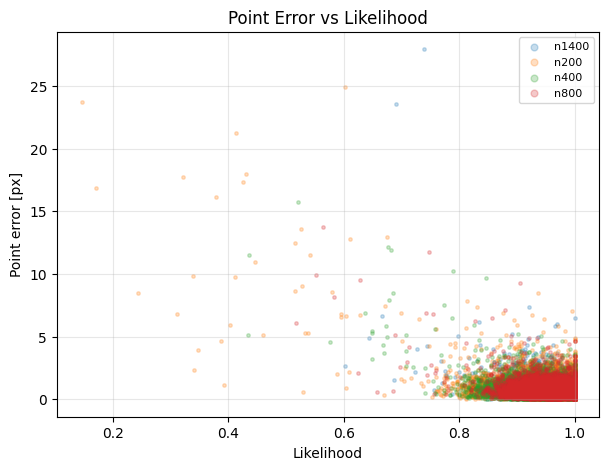

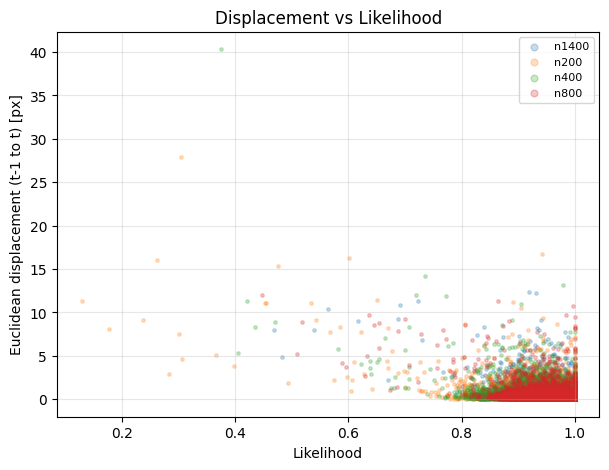

In [75]:


# ----------------------------
# Plots: model type comparisons
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(summary_df["model"], summary_df["rmse_px"])
axes[0].set_title("Model vs RMSE")
axes[0].set_ylabel("RMSE (px)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(summary_df["model"], summary_df["percent_frames_all_points_within_threshold"])
axes[1].set_title("Model vs % Frames (all points within threshold)")
axes[1].set_ylabel("Percent (%)")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(summary_df["model"], summary_df["percent_points_within_threshold"])
axes[2].set_title("Model vs % Points within threshold")
axes[2].set_ylabel("Percent (%)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# RMSE vs likelihood (model-level)
plt.figure(figsize=(6, 5))
plt.scatter(summary_df["mean_likelihood"], summary_df["rmse_px"])
for _, r in summary_df.iterrows():
    plt.annotate(r["model"], (r["mean_likelihood"], r["rmse_px"]), fontsize=8, alpha=0.9)
plt.xlabel("Mean likelihood")
plt.ylabel("RMSE (px)")
plt.title("RMSE vs Likelihood (model-level)")
plt.grid(True, alpha=0.3)
plt.show()


# Point-level error vs likelihood
if all_error_rows:
    error_df = pd.concat(all_error_rows, ignore_index=True)

    if len(error_df) > POINT_ERROR_SCATTER_MAX_POINTS:
        error_plot_df = error_df.sample(POINT_ERROR_SCATTER_MAX_POINTS, random_state=42)
    else:
        error_plot_df = error_df

    plt.figure(figsize=(7, 5))
    for model_name, g in error_plot_df.groupby("model"):
        plt.scatter(
            g["likelihood"],
            g["distance_px"],
            s=6,
            alpha=0.25,
            label=model_name,
        )
    plt.xlabel("Likelihood")
    plt.ylabel("Point error [px]")
    plt.title("Point Error vs Likelihood")
    plt.legend(markerscale=2, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No point-level error rows available for error-vs-likelihood plot.")


# Euclidean displacement vs likelihood (point-level)
if all_displacement_rows:
    disp_df = pd.concat(all_displacement_rows, ignore_index=True)

    if len(disp_df) > DISPLACEMENT_SCATTER_MAX_POINTS:
        disp_plot_df = disp_df.sample(DISPLACEMENT_SCATTER_MAX_POINTS, random_state=42)
    else:
        disp_plot_df = disp_df

    plt.figure(figsize=(7, 5))
    for model_name, g in disp_plot_df.groupby("model"):
        plt.scatter(
            g["likelihood"],
            g["euclidean_displacement_t-1_to_t"],
            s=6,
            alpha=0.25,
            label=model_name,
        )
    plt.xlabel("Likelihood")
    plt.ylabel("Euclidean displacement (t-1 to t) [px]")
    plt.title("Displacement vs Likelihood")
    plt.legend(markerscale=2, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No displacement rows available for displacement-vs-likelihood plot.")

In [101]:
# Interactive diagnostics: marginal distributions + model/scale toggles
# Run Cell 12 first so `all_error_rows` and `all_displacement_rows` are populated.

import numpy as np
import ipywidgets as widgets
from IPython.display import display

if "all_error_rows" not in globals() or not all_error_rows:
    raise RuntimeError("Run Cell 12 first to compute point-level error rows.")
if "all_displacement_rows" not in globals() or not all_displacement_rows:
    raise RuntimeError("Run Cell 12 first to compute displacement rows.")

error_df = pd.concat(all_error_rows, ignore_index=True)
disp_df = pd.concat(all_displacement_rows, ignore_index=True)

available_models = sorted(set(error_df["model"]).intersection(set(disp_df["model"])))
if not available_models:
    raise RuntimeError("No overlapping models found between error and displacement data.")


def transform_likelihood(values: np.ndarray, scale_mode: str) -> tuple[np.ndarray, str, tuple[float, float] | None]:
    """Transform likelihood values for x-axis visualization.

    Args:
        values: Raw likelihood values in [0, 1].
        scale_mode: Name of the likelihood scaling mode.

    Returns:
        Tuple of transformed values, x-axis label, and optional x-limits.
    """
    x = np.asarray(values, dtype=float)
    eps = 1e-6

    if scale_mode == "raw_0_to_1":
        return x, "Likelihood", (0.0, 1.0)

    if scale_mode == "raw_zoom_0.6_to_1":
        return x, "Likelihood", (0.6, 1.0)

    if scale_mode == "raw_zoom_0.2_to_1":
        return x, "Likelihood", (0.2, 1.0)

    if scale_mode == "neglog10_1_minus_likelihood":
        y = -np.log10(np.clip(1.0 - x, eps, None))
        return y, "-log10(1 - likelihood)", None

    if scale_mode == "logit_likelihood":
        x_clip = np.clip(x, eps, 1.0 - eps)
        y = np.log(x_clip / (1.0 - x_clip))
        return y, "logit(likelihood)", None

    return x, "Likelihood", (0.0, 1.0)


def transform_y(values: np.ndarray, scale_mode: str, base_label: str) -> tuple[np.ndarray, str]:
    """Transform y-values for point error/displacement visualization.

    Args:
        values: Raw y-values.
        scale_mode: One of raw, log1p, sqrt, asinh, log10.
        base_label: Human-readable label for the untransformed metric.

    Returns:
        Tuple of transformed y-values and the corresponding axis label.
    """
    y = np.asarray(values, dtype=float)
    eps = 1e-8

    if scale_mode == "raw":
        return y, base_label

    if scale_mode == "log1p":
        return np.log1p(np.clip(y, 0.0, None)), f"log1p({base_label})"

    if scale_mode == "sqrt":
        return np.sqrt(np.clip(y, 0.0, None)), f"sqrt({base_label})"

    if scale_mode == "asinh":
        return np.arcsinh(y), f"asinh({base_label})"

    if scale_mode == "log10":
        return np.log10(np.clip(y, eps, None)), f"log10({base_label})"

    return y, base_label


def y_limits_from_mode(y_values: np.ndarray, mode: str) -> tuple[float, float] | None:
    """Compute optional y-limits using percentile clipping.

    Args:
        y_values: Candidate y-values after any y-axis transformation.
        mode: Clipping mode. Supported: auto, p995, p99, p95.

    Returns:
        (ymin, ymax) when clipping is enabled and valid, else None.
    """
    y = np.asarray(y_values, dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return None

    if mode == "auto":
        return None

    if mode == "p99":
        lo = float(np.nanmin(y))
        hi = float(np.nanpercentile(y, 99.0))
    elif mode == "p995":
        lo = float(np.nanmin(y))
        hi = float(np.nanpercentile(y, 99.5))
    elif mode == "p95":
        lo = float(np.nanmin(y))
        hi = float(np.nanpercentile(y, 95.0))
    else:
        return None

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return None

    return (lo, hi)


def draw_joint_with_marginals(
    fig: plt.Figure,
    gs,
    data: pd.DataFrame,
    y_col: str,
    y_label: str,
    title: str,
    model_order: list[str],
    model_colors: dict[str, str],
    x_label: str,
    xlim: tuple[float, float] | None,
    ylim: tuple[float, float] | None,
):
    """Draw a scatter plot with top/right marginal histograms.

    Args:
        fig: Target matplotlib figure.
        gs: 2x2 subgridspec for top/main/right axes layout.
        data: DataFrame containing x_plot, model, and a selected y column.
        y_col: Name of y-value column to plot.
        y_label: Y-axis label text.
        title: Plot title text.
        model_order: Ordered model names to plot.
        model_colors: Mapping from model name to matplotlib color.
        x_label: X-axis label text.
        xlim: Optional x-axis limits.
        ylim: Optional y-axis limits.
    """
    ax_top = fig.add_subplot(gs[0, 0])
    ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

    for model in model_order:
        md = data[data["model"] == model]
        if md.empty:
            continue

        c = model_colors[model]
        ax_main.scatter(md["x_plot"], md[y_col], s=8, alpha=0.25, color=c, label=model)
        ax_top.hist(md["x_plot"], bins=60, alpha=0.35, color=c, density=True)
        ax_right.hist(md[y_col], bins=60, alpha=0.35, color=c, density=True, orientation="horizontal")

    if xlim is not None:
        ax_main.set_xlim(*xlim)
    if ylim is not None:
        ax_main.set_ylim(*ylim)

    ax_main.set_xlabel(x_label)
    ax_main.set_ylabel(y_label)
    ax_main.set_title(title)
    ax_main.grid(True, alpha=0.25)

    ax_top.set_ylabel("Density")
    ax_top.grid(True, alpha=0.2)

    ax_right.set_xlabel("Density")
    ax_right.grid(True, alpha=0.2)

    ax_top.tick_params(labelbottom=False)
    ax_right.tick_params(labelleft=False)


model_select = widgets.SelectMultiple(
    options=available_models,
    value=tuple(available_models),
    description="Models",
    rows=min(8, len(available_models)),
    layout=widgets.Layout(width="360px"),
)

x_scale_dropdown = widgets.Dropdown(
    options=[
        ("Raw (0 to 1)", "raw_0_to_1"),
        ("Raw zoom (0.6 to 1)", "raw_zoom_0.6_to_1"),
        ("Raw zoom (0.2 to 1)", "raw_zoom_0.2_to_1"),
        ("-log10(1-likelihood)", "neglog10_1_minus_likelihood"),
        ("logit(likelihood)", "logit_likelihood"),
    ],
    value="neglog10_1_minus_likelihood",
    description="X scale",
    layout=widgets.Layout(width="360px"),
)

y_scale_error_dropdown = widgets.Dropdown(
    options=[
        ("Raw", "raw"),
        ("log1p", "log1p"),
        ("sqrt", "sqrt"),
        ("asinh", "asinh"),
        ("log10", "log10"),
    ],
    value="raw",
    description="Y error",
    layout=widgets.Layout(width="360px"),
)

y_scale_disp_dropdown = widgets.Dropdown(
    options=[
        ("Raw", "raw"),
        ("log1p", "log1p"),
        ("sqrt", "sqrt"),
        ("asinh", "asinh"),
        ("log10", "log10"),
    ],
    value="raw",
    description="Y disp",
    layout=widgets.Layout(width="360px"),
)

y_zoom_mode_dropdown = widgets.Dropdown(
    options=[
        ("Auto", "auto"),
        ("Clip at 99.5th pct", "p995"),
        ("Clip at 99th pct", "p99"),
        ("Clip at 95th pct", "p95"),
    ],
    value="auto",
    description="Y zoom",
    layout=widgets.Layout(width="360px"),
)

max_points_slider = widgets.IntSlider(
    value=50000,
    min=5000,
    max=250000,
    step=5000,
    description="Max points",
    continuous_update=False,
    layout=widgets.Layout(width="360px"),
)

refresh_btn = widgets.Button(
    description="Refresh plots",
    button_style="primary",
    layout=widgets.Layout(width="160px"),
)

out = widgets.Output()


def render(_=None):
    """Render both interactive diagnostic panels using current widget state.

    This callback filters selected models, applies axis transforms,
    clips y-ranges when requested, and redraws the point-error and
    displacement joint+marginal plots.
    """
    with out:
        out.clear_output(wait=True)

        selected_models = list(model_select.value)
        if not selected_models:
            print("Select at least one model.")
            return

        err = error_df[error_df["model"].isin(selected_models)].dropna(subset=["likelihood", "distance_px"]).copy()
        dsp = disp_df[disp_df["model"].isin(selected_models)].dropna(subset=["likelihood", "euclidean_displacement_t-1_to_t"]).copy()

        if err.empty or dsp.empty:
            print("No data available for current selection.")
            return

        max_points = int(max_points_slider.value)
        if len(err) > max_points:
            err = err.sample(max_points, random_state=42)
        if len(dsp) > max_points:
            dsp = dsp.sample(max_points, random_state=42)

        err["x_plot"], x_label, xlim = transform_likelihood(err["likelihood"].to_numpy(dtype=float), x_scale_dropdown.value)
        dsp["x_plot"], _, _ = transform_likelihood(dsp["likelihood"].to_numpy(dtype=float), x_scale_dropdown.value)

        err["y_plot"], err_y_label = transform_y(
            err["distance_px"].to_numpy(dtype=float),
            y_scale_error_dropdown.value,
            "Point error [px]",
        )
        dsp["y_plot"], dsp_y_label = transform_y(
            dsp["euclidean_displacement_t-1_to_t"].to_numpy(dtype=float),
            y_scale_disp_dropdown.value,
            "Euclidean displacement (t-1 to t) [px]",
        )

        err_ylim = y_limits_from_mode(err["y_plot"].to_numpy(dtype=float), y_zoom_mode_dropdown.value)
        dsp_ylim = y_limits_from_mode(dsp["y_plot"].to_numpy(dtype=float), y_zoom_mode_dropdown.value)

        cmap = plt.get_cmap("tab10")
        model_colors = {m: cmap(i % 10) for i, m in enumerate(selected_models)}

        fig = plt.figure(figsize=(16, 10))
        outer = fig.add_gridspec(2, 2, width_ratios=[5, 1.3], height_ratios=[1, 1], hspace=0.35, wspace=0.18)

        gs_top = outer[0, :].subgridspec(2, 2, width_ratios=[5, 1.3], height_ratios=[1.2, 4], hspace=0.05, wspace=0.05)
        draw_joint_with_marginals(
            fig=fig,
            gs=gs_top,
            data=err,
            y_col="y_plot",
            y_label=err_y_label,
            title="Point Error vs Likelihood (with marginals)",
            model_order=selected_models,
            model_colors=model_colors,
            x_label=x_label,
            xlim=xlim,
            ylim=err_ylim,
        )

        gs_bottom = outer[1, :].subgridspec(2, 2, width_ratios=[5, 1.3], height_ratios=[1.2, 4], hspace=0.05, wspace=0.05)
        draw_joint_with_marginals(
            fig=fig,
            gs=gs_bottom,
            data=dsp,
            y_col="y_plot",
            y_label=dsp_y_label,
            title="Displacement vs Likelihood (with marginals)",
            model_order=selected_models,
            model_colors=model_colors,
            x_label=x_label,
            xlim=xlim,
            ylim=dsp_ylim,
        )

        handles = [
            plt.Line2D([0], [0], marker="o", linestyle="", color=model_colors[m], label=m, markersize=7)
            for m in selected_models
        ]
        fig.legend(
            handles=handles,
            loc="upper center",
            ncol=min(4, len(selected_models)),
            frameon=False,
            bbox_to_anchor=(0.5, 1.0),
        )

        plt.show()


refresh_btn.on_click(render)
controls = widgets.VBox(
    [
        model_select,
        x_scale_dropdown,
        y_scale_error_dropdown,
        y_scale_disp_dropdown,
        y_zoom_mode_dropdown,
        max_points_slider,
        refresh_btn,
    ]
)
display(widgets.HBox([controls, out]))
render()

# ----------------------------------------------------------- #

# ----------------------------------------------------------- #

# ----------------------------------------------------------- #

# David Bowie Testing

This section runs the same model-comparison analysis for David Bowie which has two trained model suites, one trained on trial 17 and one trained on trial 15

### Testing on the rest of the frames from trial 15 with model trained on 15

In [143]:
# Endive: find union of frames used for training, then list frames not used.

image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
DAVID_BOWIE_ROOT = DEEPLABCUT_ROOT / "DavidBowie"
DAVID_BOWIE_TRAINING_DIR = DAVID_BOWIE_ROOT / "TrainingData_T15"


def extract_frame_number_from_stem(stem: str) -> int | None:
    # Example stem: Endive_20251606_F32_cam1_0521 -> frame 521
    match = re.search(r"(\d+)$", stem)
    if not match:
        return None
    return int(match.group(1))


DB_config_paths = discover_model_configs(DAVID_BOWIE_ROOT )
if not DB_config_paths:
    raise FileNotFoundError(f"No David Bowie model config files found under {DAVID_BOWIE_ROOT / 'ModelBuildExperiments'}")

# Union of all frame IDs used by any David Bowie model.
DB_used_frames_union: set[int] = set()
per_model_frame_counts: list[dict[str, Any]] = []

for config_path in sorted(DB_config_paths):
    # ensure that it is trial 15 if T15
    
    if str(config_path).find("T15") == -1 :
        print(f"Skipping {config_path} since it is not trial 15")
        continue
    print(f"Processing David Bowie model config: {config_path}")
    labeled_dir = config_path.parent / "labeled-data"
    image_paths = [
        p for p in labeled_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in image_exts
    ]

    frame_ids = {
        frame_id
        for p in image_paths
        for frame_id in [extract_frame_number_from_stem(p.stem)]
        if frame_id is not None
    }

    DB_used_frames_union.update(frame_ids)
    per_model_frame_counts.append(
        {
            "model": config_path.parent.name,
            "n_unique_frames_used": len(frame_ids),
            "labeled_data_dir": str(labeled_dir),
        }
    )

# Determine all available frame IDs from David Bowie trainingdata CSV.
print(DAVID_BOWIE_TRAINING_DIR)
training_csvs = sorted(DAVID_BOWIE_TRAINING_DIR.glob("*.csv"))
if not training_csvs:
    raise FileNotFoundError(f"No CSV files found in {DAVID_BOWIE_TRAINING_DIR}")

david_bowie_training_csv_path = training_csvs[0]
david_bowie_training_df = pd.read_csv(david_bowie_training_csv_path)

# CSV rows correspond to frames; use 1-based IDs to match image naming like ..._0001.
david_bowie_all_training_frames = set(range(1, len(david_bowie_training_df) + 1))

# Frames present in trainingdata but never used by any model's labeled-data.
david_bowie_unused_training_frames = sorted(david_bowie_all_training_frames - DB_used_frames_union)

# Also keep used-in-trainingdata intersection for sanity checks.
david_bowie_used_training_frames = sorted(david_bowie_all_training_frames & DB_used_frames_union)

print(f"Training CSV: {david_bowie_training_csv_path}")
print(f"Total frames in trainingdata CSV: {len(david_bowie_all_training_frames)}")
print(f"Union of used frames across David Bowie models: {len(DB_used_frames_union)}")
print(f"Used frames that are in trainingdata: {len(david_bowie_used_training_frames)}")
print(f"Unused frames in trainingdata: {len(david_bowie_unused_training_frames)}")

# Requested output list.
david_bowie_unused_training_frames[:25], david_bowie_unused_training_frames[-25:]

Skipping c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n1400_T17\Canari-Tyler-2026-04-22\config.yaml since it is not trial 15
Processing David Bowie model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15\Canari-Tyler-2026-04-24\config.yaml
Skipping c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T17\Canari-Tyler-2026-04-22\config.yaml since it is not trial 15
Processing David Bowie model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n400_T15\Canari-Tyler-2026-04-24\config.yaml
Skipping c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n400_T17\Canari-Tyler-2

([2,
  3,
  4,
  5,
  6,
  7,
  9,
  11,
  13,
  14,
  15,
  16,
  17,
  20,
  23,
  25,
  27,
  29,
  30,
  31,
  32,
  33,
  34,
  36,
  38],
 [2945,
  2947,
  2948,
  2949,
  2950,
  2952,
  2954,
  2956,
  2957,
  2958,
  2959,
  2963,
  2964,
  2965,
  2966,
  2967,
  2968,
  2969,
  2970,
  2972,
  2973,
  2974,
  2975,
  2979,
  2980])

,src_video,dst_video,requested_frames,written_frames,missing_frames,fps,width,height
0,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,2180,2180,0,30.0,768,768
1,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,2180,2180,0,30.0,768,768


Skipping c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n1400_T17\Canari-Tyler-2026-04-22\config.yaml since it is not trial 15
Analyzing videos with c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15\Canari-Tyler-2026-04-24\dlc-models-pytorch\iteration-0\CanariApr24-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariApr24shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\sv\uf_cam2.avi
Video metadata: 
  Overall # of frames:    2180
  Duration of video [s]:  72.67
  fps:                    30.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2180/2180 [01:01<00:00, 35.33it/s]


Saving results in c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\Train15_Eval15\DavidBowie_n200_T15\uf_cam2DLC_Resnet50_CanariApr24shuffle1_snapshot_200.h5 and c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\Train15_Eval15\DavidBowie_n200_T15\uf_cam2DLC_Resnet50_CanariApr24shuffle1_snapshot_200_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\sv\uf_cam1.avi
Video metadata: 
  Overall # of frames:    2180
  Duration of video [s]:  72.67
  fps:                    30.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2180/2180 [01:01<00:00, 35.40it/s]


...

100%|██████████| 2180/2180 [00:16<00:00, 128.57it/s]


Starting to process video: c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/sv/uf_cam2.avi
Loading c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/sv/uf_cam2.avi and data.
Duration of video [s]: 72.67, recorded with 30.0 fps!
Overall # of frames: 2180 with cropped frame dimensions: 768 768
Generating frames and creating video.


100%|██████████| 2180/2180 [00:19<00:00, 114.49it/s]


Loading  c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/sv/uf_cam1.avi and data.
Loading  c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/sv/uf_cam2.avi and data.
Plots created! Please check the directory "plot-poses" within the video directory
Skipping c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n800_T17\Canari-Tyler-2026-04-22\config.yaml since it is not trial 15
Batch root: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch
RUN_DAVID_BOWIE_UNUSED_FRAME_BATCH = True


,model,config,output_dir,n_subset_videos,status,error,meta_created,videos_missing_meta,n_csv_files,n_labeled_videos,n_trajectory_plot_dirs
0,DavidBowie_n200_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,2,done,None,0,0,2,2,1
1,DavidBowie_n400_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,2,done,None,0,0,2,2,1
2,DavidBowie_n800_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,2,done,None,0,0,2,2,1


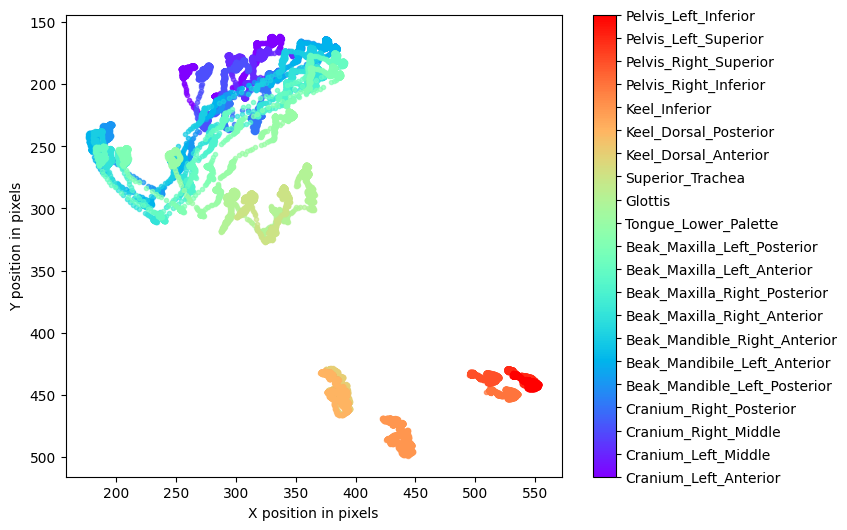

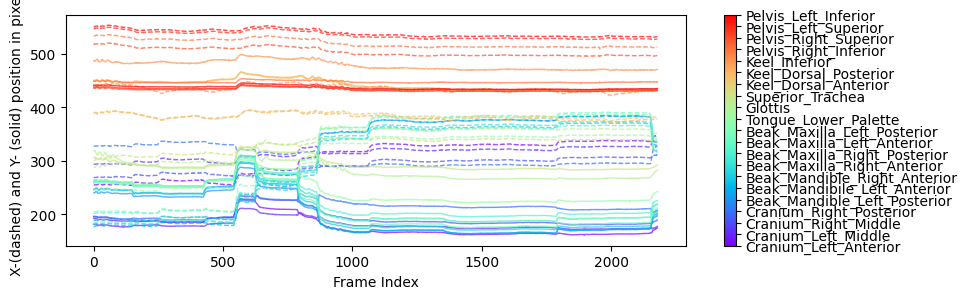

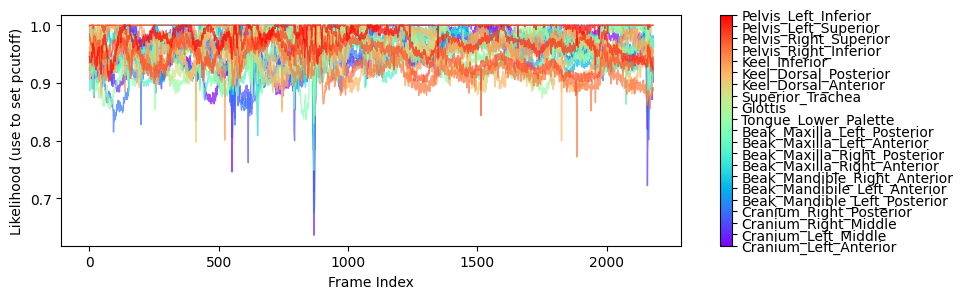

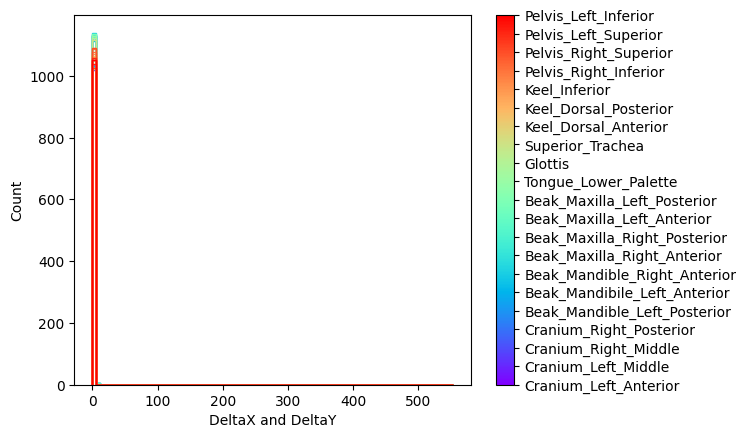

In [147]:
# ----------------------------
# David Bowie unused-frame batch inference
# ----------------------------
RUN_DAVID_BOWIE_UNUSED_FRAME_BATCH = True

DAVID_BOWIE_EXPERIMENT_EVAL_DIR = DAVID_BOWIE_ROOT / "ExperimentEval"
# Keep paths short on Windows to avoid MAX_PATH issues with DLC filenames.
DAVID_BOWIE_BATCH_ROOT = DAVID_BOWIE_EXPERIMENT_EVAL_DIR / "UFBatch"

# Source videos from David Bowie trainingdata. Both cam1 and cam2 are supported.
DAVID_BOWIE_SOURCE_VIDEOS = sorted(DAVID_BOWIE_TRAINING_DIR.glob("*.avi"))



if not DAVID_BOWIE_SOURCE_VIDEOS:
    raise FileNotFoundError(f"No source .avi files found in {DAVID_BOWIE_TRAINING_DIR}")

if "david_bowie_unused_training_frames" not in globals():
    raise RuntimeError(
        "`david_bowie_unused_training_frames` was not found. Run Cell 7 first to generate it."
    )

# Build subset (unlabeled) AVI once, then reuse for all models.
subset_video_dir = DAVID_BOWIE_BATCH_ROOT / "sv"
subset_build_log: list[dict[str, Any]] = []
subset_videos: list[Path] = []

for src_video in DAVID_BOWIE_SOURCE_VIDEOS:
    cam_tag = "cam2" if "cam2" in src_video.stem.lower() else "cam1"
    subset_name = f"uf_{cam_tag}.avi"
    subset_path = subset_video_dir / subset_name
    subset_videos.append(subset_path)

    if RUN_DAVID_BOWIE_UNUSED_FRAME_BATCH:
        info = build_subset_video_from_frame_ids(
            src_video=src_video,
            dst_video=subset_path,
            frame_ids_1_based=david_bowie_unused_training_frames,
        )
        subset_build_log.append(info)

if RUN_DAVID_BOWIE_UNUSED_FRAME_BATCH and subset_build_log:
    display(pd.DataFrame(subset_build_log))

# Run all David Bowie models and write outputs to per-model folders.
# Note: we reference shared subset_videos directly and do not copy unlabeled videos into each model folder.
David_Bowie_model_configs = sorted(discover_model_configs(DAVID_BOWIE_ROOT))
batch_rows: list[dict[str, Any]] = []

if RUN_DAVID_BOWIE_UNUSED_FRAME_BATCH:
    import deeplabcut

DAVID_BOWIE_TRAIN15_EVAL15_DIR = DAVID_BOWIE_BATCH_ROOT / "Train15_Eval15"
DAVID_BOWIE_TRAIN15_EVAL15_DIR.mkdir(parents=True, exist_ok=True)

for config_path in David_Bowie_model_configs:
    if str(config_path).find("T15") == -1 :
        print(f"Skipping {config_path} since it is not trial 15")
        continue
    n_folder = config_path.parent.parent.name  # e.g., Canari_combined_n200
    n_token = n_folder.replace("Canari_combined_", "")  # e.g., n200
    model_slug = n_token
    model_out_dir = DAVID_BOWIE_TRAIN15_EVAL15_DIR / model_slug
    model_out_dir.mkdir(parents=True, exist_ok=True)

    row: dict[str, Any] = {
        "model": model_slug,
        "config": str(config_path),
        "output_dir": str(model_out_dir),
        "n_subset_videos": len(subset_videos),
        "status": "ready" if not RUN_DAVID_BOWIE_UNUSED_FRAME_BATCH else "running",
        "error": None,
    }

    try:
        if RUN_DAVID_BOWIE_UNUSED_FRAME_BATCH:
            missing_subset = [v for v in subset_videos if not v.exists()]
            if missing_subset:
                raise FileNotFoundError(f"Subset videos missing: {missing_subset}")

            deeplabcut.analyze_videos(
                config=as_posix_str(config_path),
                videos=[as_posix_str(v) for v in subset_videos],
                destfolder=as_posix_str(model_out_dir),
                videotype=".avi",
                save_as_csv=True,
            )

            meta_info = ensure_meta_pickles_for_videos(model_out_dir, subset_videos)
            videos_for_labeling = meta_info["videos_with_meta"]
            row["meta_created"] = int(meta_info["meta_created"])
            row["videos_missing_meta"] = len(meta_info["videos_missing_meta"])

            if videos_for_labeling:
                deeplabcut.create_labeled_video(
                    config=as_posix_str(config_path),
                    videos=[as_posix_str(v) for v in videos_for_labeling],
                    destfolder=as_posix_str(model_out_dir),
                    videotype=".avi",
                )
            else:
                raise FileNotFoundError(
                    "No *_meta.pickle found after analysis for any subset video. "
                    "Labeled video generation skipped."
                )

            # Also generate DLC trajectory plots for this model output.
            deeplabcut.plot_trajectories(
                as_posix_str(config_path),
                [as_posix_str(v) for v in subset_videos],
                videotype=".avi",
                destfolder=as_posix_str(model_out_dir),
            )

            row["status"] = "done"

            csv_files = sorted(model_out_dir.glob("*DLC*.csv"))
            labeled_videos = sorted(model_out_dir.glob("*labeled*.*"))
            traj_plots = sorted(model_out_dir.glob("*plot-poses*"))

            row["n_csv_files"] = len(csv_files)
            row["n_labeled_videos"] = len(labeled_videos)
            row["n_trajectory_plot_dirs"] = len(traj_plots)
    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)

    batch_rows.append(row)

batch_df = pd.DataFrame(batch_rows)
print(f"Batch root: {DAVID_BOWIE_BATCH_ROOT}")
print(f"RUN_DAVID_BOWIE_UNUSED_FRAME_BATCH = {RUN_DAVID_BOWIE_UNUSED_FRAME_BATCH}")
batch_df

WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch')

In [186]:
# David Bowie model-vs-truth comparison on unused-frame subset

#### Figure out threshold for good vs bad predictions. Options:
# - RMSE-based: compute RMSE across all predictions for a model, then use that as a threshold for "good" vs "bad" predictions. This is relative to each model's overall performance.
# - Fixed threshold: use a fixed pixel distance (e.g., 8px) as the cutoff for good vs bad predictions. This is absolute and consistent across models.
# what else...



# ----------------------------
# Configuration
# ----------------------------
THRESHOLD_MODE = "rmse"   # "rmse" or "fixed"
FIXED_THRESHOLD_PX = 8.0   # used only when THRESHOLD_MODE == "fixed"
DISPLACEMENT_SCATTER_MAX_POINTS = 50000
POINT_ERROR_SCATTER_MAX_POINTS = 50000



# ----------------------------
# Data loading
# ----------------------------
if "DAVID_BOWIE_BATCH_ROOT" not in globals():
    raise RuntimeError("Run the David Bowie batch cell first so DAVID_BOWIE_BATCH_ROOT is defined.")

if "david_bowie_unused_training_frames" not in globals():
    raise RuntimeError("Run Cell 7 first so david_bowie_unused_training_frames exists.")

frame_id_lookup = sorted(set(david_bowie_unused_training_frames))

if "david_bowie_training_csv_path" in globals():
    truth_csv_path = Path(david_bowie_training_csv_path)
else:
    truth_csvs = sorted((DAVID_BOWIE_ROOT / "TrainingData_T15" ).glob("*.csv"))
    if not truth_csvs:
        raise FileNotFoundError("No David Bowie training truth CSV found.")
    truth_csv_path = truth_csvs[0]

truth_long = truth_csv_to_long(truth_csv_path)

model_dirs = sorted([p for p in DAVID_BOWIE_TRAIN15_EVAL15_DIR.iterdir() if p.is_dir() and "_T15" in p.name])

summary_rows = []
all_displacement_rows = []
all_error_rows = []

for model_dir in model_dirs:
    pred_csvs = sorted(model_dir.glob("*DLC*.csv"))
    if not pred_csvs:
        continue

    pred_long_parts = [prediction_csv_to_long(p, frame_id_lookup) for p in pred_csvs]
    pred_long = pd.concat(pred_long_parts, ignore_index=True)

    merged = pred_long.merge(
        truth_long,
        on=["frame_id", "bodypart", "camera"],
        how="inner",
    )

    merged = merged.dropna(subset=["frame_id", "x_pred", "y_pred", "x_true", "y_true"]).copy()
    if merged.empty:
        continue

    merged["distance_px"] = np.sqrt((merged["x_pred"] - merged["x_true"]) ** 2 + (merged["y_pred"] - merged["y_true"]) ** 2)

    error_rows = merged[["camera", "bodypart", "frame_id", "distance_px", "likelihood"]].copy()
    error_rows["model"] = model_dir.name
    error_rows['train_trial'] = 15
    error_rows['eval_trial'] = 15
    error_rows['pair'] = "Train15_Eval15"
    error_rows = error_rows[["model", "camera", "bodypart", "frame_id", "distance_px", "likelihood", "train_trial", "eval_trial", "pair"]]
    all_error_rows.append(error_rows)

    rmse = float(np.sqrt(np.mean(np.square(merged["distance_px"]))))
    threshold_px = rmse if THRESHOLD_MODE == "rmse" else float(FIXED_THRESHOLD_PX)

    merged["within_threshold"] = merged["distance_px"] <= FIXED_THRESHOLD_PX

    # Percent points within threshold
    pct_points = 100.0 * float(merged["within_threshold"].mean())

    # Percent frames where all predicted points are within threshold
    expected_per_frame = pred_long[["camera", "bodypart"]].drop_duplicates().shape[0]

    frame_stats = (
        merged.groupby("frame_id", as_index=False)
        .agg(
            n_points=("within_threshold", "size"),
            all_within=("within_threshold", "all"),
        )
    )
    frame_stats["frame_pass"] = frame_stats["all_within"] & (frame_stats["n_points"] == expected_per_frame)
    pct_frames = 100.0 * float(frame_stats["frame_pass"].mean())

    mean_likelihood = float(np.nanmean(merged["likelihood"])) if "likelihood" in merged.columns else np.nan

    summary_rows.append(
        {
            "model": model_dir.name,
            "rmse_px": rmse,
            "threshold_px": threshold_px,
            "percent_frames_all_points_within_threshold": pct_frames,
            "percent_points_within_threshold": pct_points,
            "mean_likelihood": mean_likelihood,
            "n_points": int(merged.shape[0]),
        }
    )

    # Euclidean displacement from frame t-1 to t and likelihood
    disp = merged.sort_values(["camera", "bodypart", "frame_id"]).copy()
    disp["dx"] = disp.groupby(["camera", "bodypart"])["x_pred"].diff()
    disp["dy"] = disp.groupby(["camera", "bodypart"])["y_pred"].diff()
    disp["euclidean_displacement_t-1_to_t"] = np.sqrt(disp["dx"] ** 2 + disp["dy"] ** 2)
    disp = disp.dropna(subset=["euclidean_displacement_t-1_to_t"])

    if not disp.empty:
        disp["model"] = model_dir.name
        disp = disp[["model", "camera", "bodypart", "frame_id", "euclidean_displacement_t-1_to_t", "likelihood"]]
        all_displacement_rows.append(disp)

summary_df = pd.DataFrame(summary_rows).sort_values("model").reset_index(drop=True)

if summary_df.empty:
    raise RuntimeError("No comparable prediction CSV data found in model output folders.")
summary_df["train_trial"] = 15
summary_df["eval_trial"] = 15
summary_df['pair'] = f"Train15_Eval15"
summary_df['model'] = summary_df['model'].apply(lambda x: f"{x}")
print("Summary DF")
display(summary_df)
error_df = pd.concat(all_error_rows, ignore_index=True)
error_df['model'] = error_df['model'].apply(lambda x: f"DavidBowie_{x}_T15")
print(f"Total points compared across all models: {len(error_df)}")


write_summary_csv = True
if write_summary_csv:
    summary_csv_path = DAVID_BOWIE_BATCH_ROOT / "david_bowie_WithinTrial_summary_TrainTest15.csv"
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"Summary metrics written to: {summary_csv_path}")
    errors_csv_path = DAVID_BOWIE_BATCH_ROOT / "david_bowie_WithinTrial_errors_TrainTest15.csv"
    error_df.to_csv(errors_csv_path, index=False)
    print(f"All point errors written to: {errors_csv_path}")
    


Summary DF


,model,rmse_px,threshold_px,percent_frames_all_points_within_threshold,percent_points_within_threshold,mean_likelihood,n_points,train_trial,eval_trial,pair
0,DavidBowie_n200_T15,0.875024,0.875024,98.577982,99.915902,0.962813,91560,15,15,Train15_Eval15
1,DavidBowie_n400_T15,0.531432,0.531432,99.816514,99.995631,0.957522,91560,15,15,Train15_Eval15
2,DavidBowie_n800_T15,0.589323,0.589323,99.770642,99.994539,0.965509,91560,15,15,Train15_Eval15


Total points compared across all models: 274680
Summary metrics written to: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\david_bowie_WithinTrial_summary_TrainTest15.csv
All point errors written to: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\david_bowie_WithinTrial_errors_TrainTest15.csv


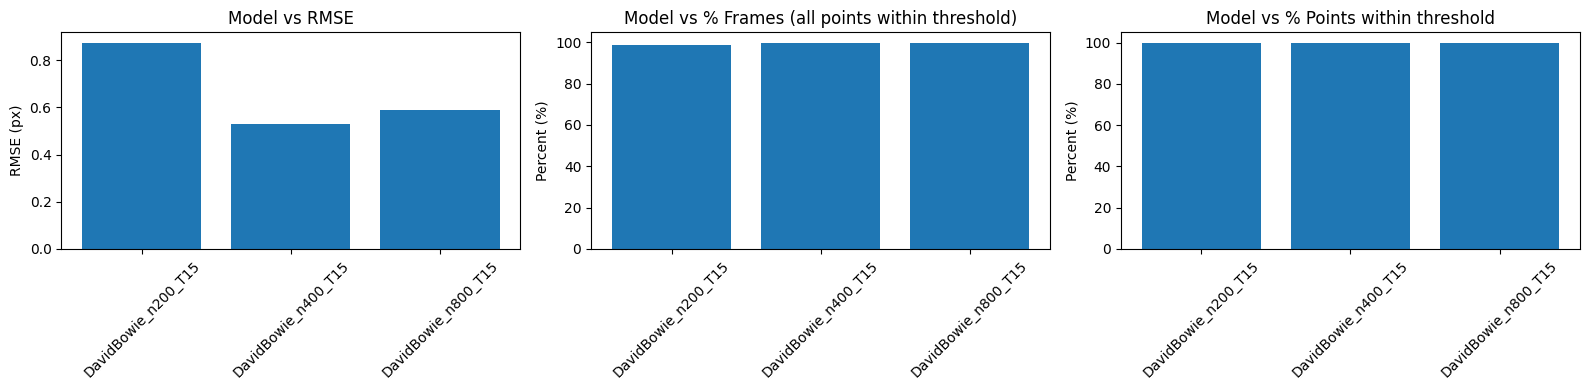

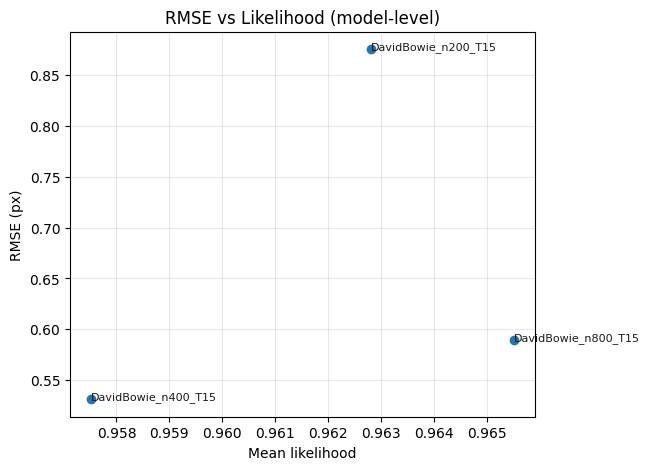

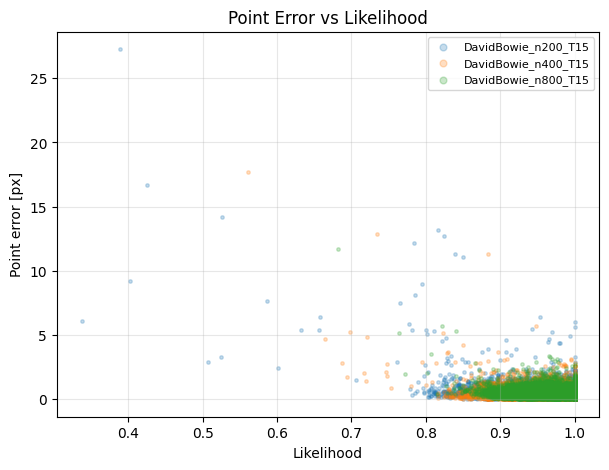

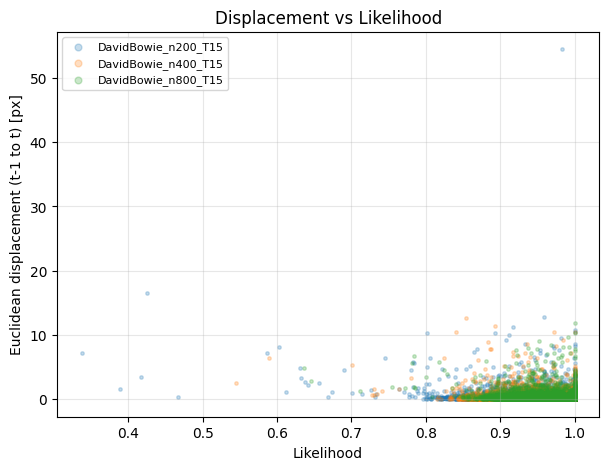

In [161]:

# ----------------------------
# Plots: model type comparisons
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(summary_df["model"], summary_df["rmse_px"])
axes[0].set_title("Model vs RMSE")
axes[0].set_ylabel("RMSE (px)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(summary_df["model"], summary_df["percent_frames_all_points_within_threshold"])
axes[1].set_title("Model vs % Frames (all points within threshold)")
axes[1].set_ylabel("Percent (%)")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(summary_df["model"], summary_df["percent_points_within_threshold"])
axes[2].set_title("Model vs % Points within threshold")
axes[2].set_ylabel("Percent (%)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# RMSE vs likelihood (model-level)
plt.figure(figsize=(6, 5))
plt.scatter(summary_df["mean_likelihood"], summary_df["rmse_px"])
for _, r in summary_df.iterrows():
    plt.annotate(r["model"], (r["mean_likelihood"], r["rmse_px"]), fontsize=8, alpha=0.9)
plt.xlabel("Mean likelihood")
plt.ylabel("RMSE (px)")
plt.title("RMSE vs Likelihood (model-level)")
plt.grid(True, alpha=0.3)
plt.show()


# Point-level error vs likelihood
if all_error_rows:
    error_df = pd.concat(all_error_rows, ignore_index=True)

    if len(error_df) > POINT_ERROR_SCATTER_MAX_POINTS:
        error_plot_df = error_df.sample(POINT_ERROR_SCATTER_MAX_POINTS, random_state=42)
    else:
        error_plot_df = error_df

    plt.figure(figsize=(7, 5))
    for model_name, g in error_plot_df.groupby("model"):
        plt.scatter(
            g["likelihood"],
            g["distance_px"],
            s=6,
            alpha=0.25,
            label=model_name,
        )
    plt.xlabel("Likelihood")
    plt.ylabel("Point error [px]")
    plt.title("Point Error vs Likelihood")
    plt.legend(markerscale=2, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No point-level error rows available for error-vs-likelihood plot.")


# Euclidean displacement vs likelihood (point-level)
if all_displacement_rows:
    disp_df = pd.concat(all_displacement_rows, ignore_index=True)

    if len(disp_df) > DISPLACEMENT_SCATTER_MAX_POINTS:
        disp_plot_df = disp_df.sample(DISPLACEMENT_SCATTER_MAX_POINTS, random_state=42)
    else:
        disp_plot_df = disp_df

    plt.figure(figsize=(7, 5))
    for model_name, g in disp_plot_df.groupby("model"):
        plt.scatter(
            g["likelihood"],
            g["euclidean_displacement_t-1_to_t"],
            s=6,
            alpha=0.25,
            label=model_name,
        )
    plt.xlabel("Likelihood")
    plt.ylabel("Euclidean displacement (t-1 to t) [px]")
    plt.title("Displacement vs Likelihood")
    plt.legend(markerscale=2, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No displacement rows available for displacement-vs-likelihood plot.")

In [ ]:
# Helper Functions for the David Bowie

def db_parse_frame_id_from_name(name: str) -> int | None:
    m = re.search(r"(\d+)(?!.*\d)", name)
    if m is None:
        return None
    return int(m.group(1))


def db_collect_images(image_dir: Path) -> list[Path]:
    if not image_dir.exists():
        return []
    image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    imgs = [p for p in image_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts]
    return sorted(
        imgs,
        key=lambda p: (
            db_parse_frame_id_from_name(p.stem) is None,
            db_parse_frame_id_from_name(p.stem) or 0,
            p.name,
        ),
    )


def db_build_video_from_images(
    image_paths: list[Path],
    out_video: Path,
    fps: float = 500.0,
    codec: str = "MJPG",
    overwrite: bool = False,
) -> dict[str, object]:
    try:
        import cv2
    except Exception as exc:
        raise ImportError("OpenCV (cv2) is required to build video clips.") from exc

    if not image_paths:
        raise ValueError(f"No images provided for {out_video}")

    if out_video.exists() and not overwrite:
        frame_ids = [db_parse_frame_id_from_name(p.stem) for p in image_paths]
        frame_ids = [int(f) for f in frame_ids if f is not None]
        return {
            "video": out_video,
            "n_frames_written": len(frame_ids),
            "frame_id_lookup": frame_ids,
            "status": "reused",
        }

    first = cv2.imread(str(image_paths[0]))
    if first is None:
        raise FileNotFoundError(f"Could not read first image: {image_paths[0]}")

    h, w = first.shape[:2]
    out_video.parent.mkdir(parents=True, exist_ok=True)
    writer = cv2.VideoWriter(str(out_video), cv2.VideoWriter_fourcc(*codec), fps, (w, h))

    written = 0
    frame_id_lookup: list[int] = []
    for p in image_paths:
        img = cv2.imread(str(p))
        if img is None:
            continue
        if img.shape[:2] != (h, w):
            img = cv2.resize(img, (w, h))
        writer.write(img)
        written += 1
        fid = db_parse_frame_id_from_name(p.stem)
        frame_id_lookup.append(fid if fid is not None else written)

    writer.release()
    return {
        "video": out_video,
        "n_frames_written": written,
        "frame_id_lookup": frame_id_lookup,
        "status": "created",
    }


def db_discover_model_configs_for_trial(root: Path, train_trial: int) -> list[Path]:
    configs = sorted((root / "ModelBuildExperiments").glob("DavidBowie*/Canari-Tyler-*/config.yaml"))
    filtered: list[Path] = []
    for cfg in configs:
        model_folder = cfg.parent.parent.name
        m = re.search(r"_T(?P<trial>\d+)$", model_folder)
        if m is None:
            continue
        if int(m.group("trial")) == train_trial:
            filtered.append(cfg)
    return filtered


def db_resolve_eval_train_dir(root: Path, eval_trial: int) -> Path:
    direct = root / f"TrainingData_T{eval_trial}"
    if direct.exists():
        return direct
    raise FileNotFoundError(f"Could not find training directory for eval trial T{eval_trial}.")


def db_resolve_cam_dir(eval_train_dir: Path, eval_trial: int, cam_idx: int) -> Path:
    expected = eval_train_dir / f"Cam{cam_idx}_Img00UND_Trial{eval_trial}"
    if expected.exists():
        return expected

    candidates = sorted(eval_train_dir.rglob(f"Cam{cam_idx}_Img00UND_Trial{eval_trial}"))
    if candidates:
        return candidates[0]

    raise FileNotFoundError(
        f"Could not find camera folder Cam{cam_idx}_Img00UND_Trial{eval_trial} under {eval_train_dir}"
    )


def db_resolve_truth_csv(eval_train_dir: Path, eval_trial: int) -> Path:
    sample_csvs = sorted(eval_train_dir.rglob(f"*T{eval_trial}*.csv"))
    for csv in sample_csvs:
        try:
            _ = truth_csv_to_long(csv)
            return csv
        except Exception:
            continue
    raise FileNotFoundError(
        f"No parseable truth CSV found for eval trial T{eval_trial} under {eval_train_dir}. "
        f"First CSVs found: {sample_csvs}"
    )


## Cross Trial Training/Eval

In [181]:
# David Bowie cross-trial pipeline (train on one trial, evaluate on the other)
from pathlib import Path
import re
import shutil

# ----------------------------
# Controls
# ----------------------------
RUN_DB_BUILD_VIDEO_CLIPS = True
RUN_DB_MODEL_BATCH = True
RUN_DB_EVALUATION = True

DB_VIDEO_FPS = 500.0
DB_VIDEO_CODEC = "MJPG"
DB_VIDEO_OVERWRITE = False

DB_BATCH_FOLDER_NAME = "UFBatch"
DB_CLIP_FOLDER_NAME = "sv"

# One direction at a time:
# - DB_TRAIN_TRIAL = 15 -> evaluate on Trial 17
# - DB_TRAIN_TRIAL = 17 -> evaluate on Trial 15
DB_TRAIN_TRIAL = 17
if DB_TRAIN_TRIAL not in {15, 17}:
    raise ValueError("DB_TRAIN_TRIAL must be 15 or 17.")
DB_EVAL_TRIAL = 17 if DB_TRAIN_TRIAL == 15 else 15
DB_PAIR_SLUG = f"TrainT{DB_TRAIN_TRIAL}_EvalT{DB_EVAL_TRIAL}"

# ----------------------------
# Base paths
# ----------------------------
DAVID_BOWIE_ROOT = DEEPLABCUT_ROOT / "DavidBowie"
DAVID_BOWIE_EVAL_DIR = DAVID_BOWIE_ROOT / "ExperimentEval"
DAVID_BOWIE_BATCH_ROOT = DAVID_BOWIE_EVAL_DIR / DB_BATCH_FOLDER_NAME
DAVID_BOWIE_PAIR_ROOT = DAVID_BOWIE_BATCH_ROOT / DB_PAIR_SLUG
DAVID_BOWIE_CLIP_DIR = DAVID_BOWIE_PAIR_ROOT / DB_CLIP_FOLDER_NAME


In [ ]:
# Run if you have not tested the model on the new videos yet
DAVID_BOWIE_BATCH_ROOT.mkdir(parents=True, exist_ok=True)
DAVID_BOWIE_PAIR_ROOT.mkdir(parents=True, exist_ok=True)
DAVID_BOWIE_CLIP_DIR.mkdir(parents=True, exist_ok=True)

print(f"David Bowie root: {DAVID_BOWIE_ROOT}")
print(f"Batch root: {DAVID_BOWIE_BATCH_ROOT}")
print(f"Pair root: {DAVID_BOWIE_PAIR_ROOT}")
print(f"Train trial: T{DB_TRAIN_TRIAL} | Eval trial: T{DB_EVAL_TRIAL}")



In [182]:
# Run with the setup cell 2 above this one...
# ----------------------------
# Resolve eval assets
# ----------------------------
DAVID_BOWIE_TRAIN_DIR = db_resolve_eval_train_dir(DAVID_BOWIE_ROOT, DB_EVAL_TRIAL)
print(f"Resolved David Bowie eval training directory: {DAVID_BOWIE_TRAIN_DIR}")
print(DB_EVAL_TRIAL)
# The truth is the only csv in the TrainDir
DAVID_BOWIE_TRUTH_CSV = next(DAVID_BOWIE_TRAIN_DIR.rglob("*.csv"))
DAVID_BOWIE_IMAGE_DIRS = [
    db_resolve_cam_dir(DAVID_BOWIE_TRAIN_DIR, DB_EVAL_TRIAL, 1),
    db_resolve_cam_dir(DAVID_BOWIE_TRAIN_DIR, DB_EVAL_TRIAL, 2),
]

print(f"Eval training dir: {DAVID_BOWIE_TRAIN_DIR}")
print(f"Eval truth CSV: {DAVID_BOWIE_TRUTH_CSV}")
for p in DAVID_BOWIE_IMAGE_DIRS:
    print(f"Eval image dir: {p}")


Resolved David Bowie eval training directory: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15
15
Eval training dir: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15
Eval truth CSV: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\CollectedData_Trial15_DB.csv
Eval image dir: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\Cam1_Img00UND_Trial15
Eval image dir: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\Cam2_Img00UND_Trial15


In [183]:


# ----------------------------
# Step 1: Build video clips from eval-trial image folders
# ----------------------------
clip_rows = []
subset_videos: list[Path] = []
frame_lookup_by_camera: dict[str, list[int]] = {}

for image_dir in DAVID_BOWIE_IMAGE_DIRS:
    camera = infer_camera_from_name(image_dir.name)
    images = db_collect_images(image_dir)
    if not images:
        raise FileNotFoundError(f"No images found in {image_dir}")

    clip_path = DAVID_BOWIE_CLIP_DIR / f"db_{camera}_T{DB_EVAL_TRIAL}.avi"
    info = db_build_video_from_images(
        image_paths=images,
        out_video=clip_path,
        fps=float(DB_VIDEO_FPS),
        codec=DB_VIDEO_CODEC,
        overwrite=bool(DB_VIDEO_OVERWRITE),
    )
    subset_videos.append(clip_path)
    frame_lookup_by_camera[camera] = info["frame_id_lookup"]
    clip_rows.append(
        {
            "train_trial": DB_TRAIN_TRIAL,
            "eval_trial": DB_EVAL_TRIAL,
            "pair": DB_PAIR_SLUG,
            "camera": camera,
            "image_dir": str(image_dir),
            "video": str(clip_path),
            "n_frames": info["n_frames_written"],
            "status": info["status"],
        }
    )

if RUN_DB_BUILD_VIDEO_CLIPS:
    print("Built/reused David Bowie video clips:")
    display(pd.DataFrame(clip_rows))
else:
    print("RUN_DB_BUILD_VIDEO_CLIPS=False; reusing existing clip metadata for frame mapping.")



Built/reused David Bowie video clips:


,train_trial,eval_trial,pair,camera,image_dir,video,n_frames,status
0,17,15,TrainT17_EvalT15,cam1,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,2980,reused
1,17,15,TrainT17_EvalT15,cam2,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,2980,reused


Discovered 4 David Bowie model config(s) for train trial T17.
 - c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n1400_T17\Canari-Tyler-2026-04-22\config.yaml
 - c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T17\Canari-Tyler-2026-04-22\config.yaml
 - c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n400_T17\Canari-Tyler-2026-04-22\config.yaml
 - c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n800_T17\Canari-Tyler-2026-04-22\config.yaml
Starting DLC batch on 4 model(s)...
{'train_trial': 17, 'eval_trial': 15, 'pair': 'TrainT17_EvalT15', 'model': 'DavidBowie_n1400_T17', 'config': 'c:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\De

100%|██████████| 2980/2980 [01:24<00:00, 35.17it/s]


Saving results in c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15\DavidBowie_n1400_T17\db_cam1_T15DLC_Resnet50_CanariApr22shuffle1_snapshot_200.h5 and c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15\DavidBowie_n1400_T17\db_cam1_T15DLC_Resnet50_CanariApr22shuffle1_snapshot_200_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15\sv\db_cam2_T15.avi
Video metadata: 
  Overall # of frames:    2980
  Duration of video [s]:  5.96
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2980/2980 [01:24<00:00, 35.21it/s]


Saving results in c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15\DavidBowie_n1400_T17\db_cam2_T15DLC_Resnet50_CanariApr22shuffle1_snapshot_200.h5 and c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15\DavidBowie_n1400_T17\db_cam2_T15DLC_Resnet50_CanariApr22shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Creating labeled videos for DavidBowie_n1400_T17...
Starting to process video: c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT17_EvalT15/sv/db_cam1_T

...

100%|██████████| 2980/2980 [00:21<00:00, 137.49it/s]


Starting to process video: c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT17_EvalT15/sv/db_cam2_T15.avi
Loading c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT17_EvalT15/sv/db_cam2_T15.avi and data.
Duration of video [s]: 5.96, recorded with 500 fps!
Overall # of frames: 2980 with cropped frame dimensions: 768 768
Generating frames and creating video.


100%|██████████| 2980/2980 [00:24<00:00, 120.67it/s]


Plotting trajectories for DavidBowie_n800_T17...
Loading  c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT17_EvalT15/sv/db_cam1_T15.avi and data.
Loading  c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT17_EvalT15/sv/db_cam2_T15.avi and data.
Plots created! Please check the directory "plot-poses" within the video directory
Pair output root: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15


,train_trial,eval_trial,pair,model,config,output_dir,n_videos,status,error,n_csv,n_labeled_outputs,n_trajectory_dirs
0,17,15,TrainT17_EvalT15,DavidBowie_n1400_T17,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,2,done,None,2,2,1
1,17,15,TrainT17_EvalT15,DavidBowie_n200_T17,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,2,done,None,2,2,1
2,17,15,TrainT17_EvalT15,DavidBowie_n400_T17,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,2,done,None,2,2,1
3,17,15,TrainT17_EvalT15,DavidBowie_n800_T17,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,2,done,None,2,2,1


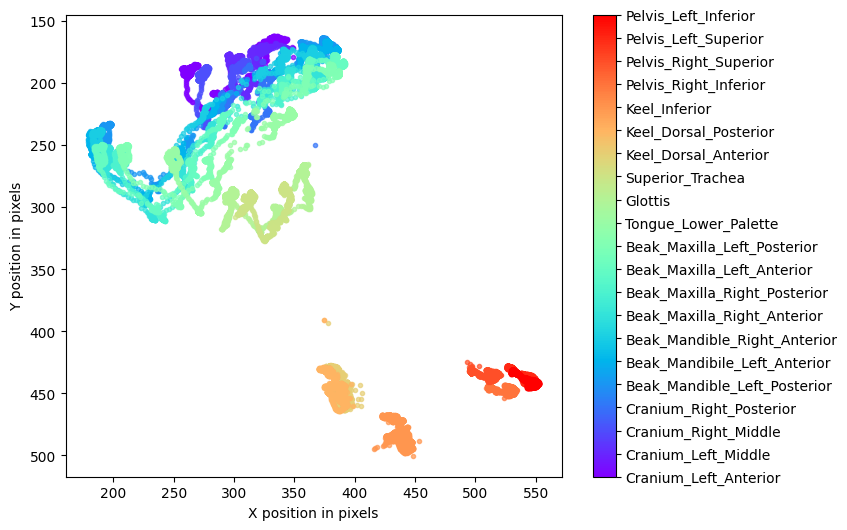

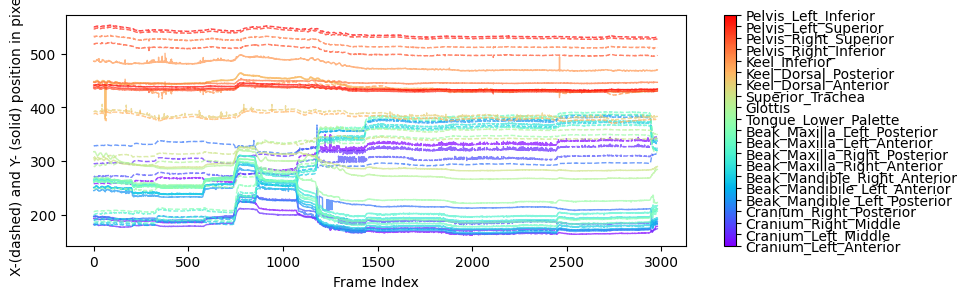

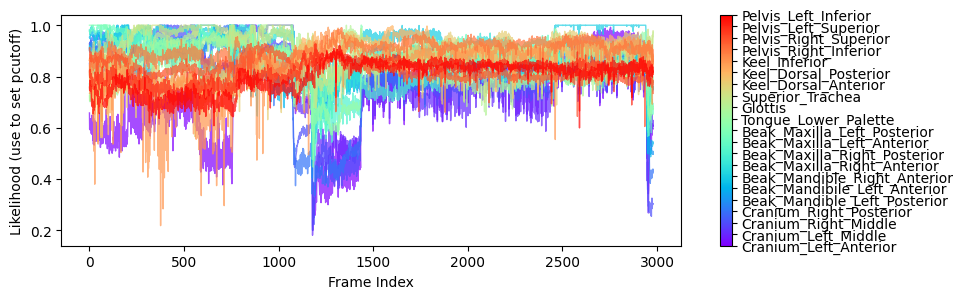

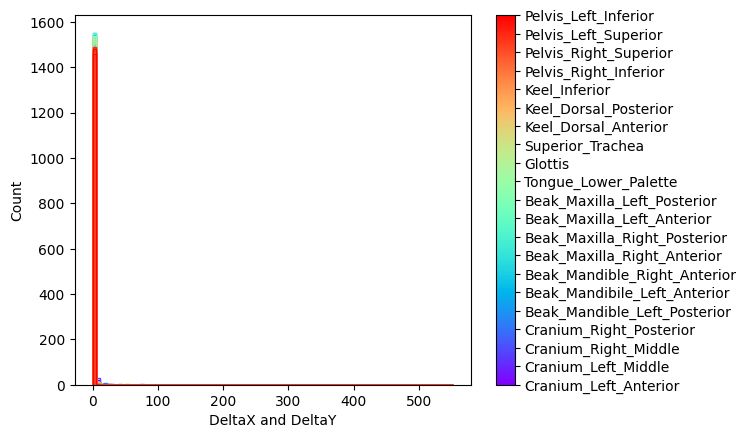

In [43]:
import deeplabcut
RUN_DB_MODEL_BATCH = True
# ----------------------------
# Step 2: DLC batch with train-trial model filtering
# ----------------------------
db_model_configs = db_discover_model_configs_for_trial(DAVID_BOWIE_ROOT, DB_TRAIN_TRIAL)
print(f"Discovered {len(db_model_configs)} David Bowie model config(s) for train trial T{DB_TRAIN_TRIAL}.")
for config in db_model_configs:
    print(f" - {config}")

if not db_model_configs:
    raise FileNotFoundError(
        f"No David Bowie model configs found for train trial T{DB_TRAIN_TRIAL} in ModelBuildExperiments."
    )

batch_rows = []
if RUN_DB_MODEL_BATCH:
    
    print(f"Starting DLC batch on {len(db_model_configs)} model(s)...")

for config_path in db_model_configs:
    n_folder = config_path.parent.parent.name
    model_slug = n_folder
    model_out_dir = DAVID_BOWIE_PAIR_ROOT / n_folder
    model_out_dir.mkdir(parents=True, exist_ok=True)

    row = {
        "train_trial": DB_TRAIN_TRIAL,
        "eval_trial": DB_EVAL_TRIAL,
        "pair": DB_PAIR_SLUG,
        "model": model_slug,
        "config": str(config_path),
        "output_dir": str(model_out_dir),
        "n_videos": len(subset_videos),
        "status": "ready" if not RUN_DB_MODEL_BATCH else "running",
        "error": None,
    }
    print(row)

    try:
        if RUN_DB_MODEL_BATCH:
            print(f"Analyzing model {model_slug}...")
            deeplabcut.analyze_videos(
                config=str(config_path.as_posix()),
                videos=[str(v.as_posix()) for v in subset_videos],
                destfolder=str(model_out_dir.as_posix()),
                videotype=".avi",
                save_as_csv=True,
            )

            print(f"Creating labeled videos for {model_slug}...")
            deeplabcut.create_labeled_video(
                config=str(config_path.as_posix()),
                videos=[str(v.as_posix()) for v in subset_videos],
                destfolder=str(model_out_dir.as_posix()),
                videotype=".avi",
            )

            print(f"Plotting trajectories for {model_slug}...")
            deeplabcut.plot_trajectories(
                config=str(config_path.as_posix()),
                videos=[str(v.as_posix()) for v in subset_videos],
                destfolder=str(model_out_dir.as_posix()),
                videotype=".avi",
            )

            row["status"] = "done"

        row["n_csv"] = len(list(model_out_dir.glob("*DLC*.csv")))
        row["n_labeled_outputs"] = len(list(model_out_dir.glob("*labeled*.*")))
        row["n_trajectory_dirs"] = len(list(model_out_dir.glob("*plot-poses*")))
    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)

    batch_rows.append(row)

print(f"Pair output root: {DAVID_BOWIE_PAIR_ROOT}")
display(pd.DataFrame(batch_rows))

if not RUN_DB_MODEL_BATCH:
    print("RUN_DB_MODEL_BATCH=False; skipping batch execution and reusing existing outputs for evaluation.")
    

In [15]:
# what is in the train dir
train_dir = DAVID_BOWIE_TRAIN_DIR
print(f"Contents of training directory ({train_dir}):")
for item in train_dir.iterdir():
    if item.is_dir():
        print(f"  [DIR] {item.name}")
    else:
        print(f"  [FILE] {item.name}")

Contents of training directory (c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17):
  [FILE] 2Dpoints_2025_08_25_DavidBowie_Subset_Trial17_UND_matches.csv
  [FILE] Cam1.avi
  [DIR] Cam1_Img00UND_Trial17
  [FILE] Cam2.avi
  [DIR] Cam2_Img00UND_Trial17
  [DIR] DavidBowie_20250828_F17


17

In [184]:



# ----------------------------
# Step 3: Evaluate predictions against eval-trial truth
# ----------------------------
THRESHOLD_MODE = "rmse"  # "rmse" or "fixed"
FIXED_THRESHOLD_PX = 8
if not RUN_DB_EVALUATION:
    print("RUN_DB_EVALUATION=False; skipping metrics and plots.")
else:
    if not DAVID_BOWIE_TRUTH_CSV.exists():
        raise FileNotFoundError(f"Truth CSV not found: {DAVID_BOWIE_TRUTH_CSV}")

    truth_long = truth_csv_to_long(DAVID_BOWIE_TRUTH_CSV)
    model_dirs = sorted([p for p in DAVID_BOWIE_PAIR_ROOT.iterdir() if p.is_dir() and f"_T{DB_TRAIN_TRIAL}" in p.name])

    db_summary_rows = []
    db_all_error_rows = []
    db_all_displacement_rows = []

    for model_dir in model_dirs:
        pred_csvs = sorted(model_dir.glob("*DLC*.csv"))
        if not pred_csvs:
            continue

        pred_long_parts = [prediction_csv_to_long(p, [], fresh_vid=True) for p in pred_csvs]
        pred_long = pd.concat(pred_long_parts, ignore_index=True)

        merged = pred_long.merge(
            truth_long,
            on=["frame_id", "bodypart", "camera"],
            how="inner",
        )
        merged = merged.dropna(subset=["frame_id", "x_pred", "y_pred", "x_true", "y_true"]).copy()
        if merged.empty:
            continue

        merged["distance_px"] = np.sqrt((merged["x_pred"] - merged["x_true"]) ** 2 + (merged["y_pred"] - merged["y_true"]) ** 2)
        error_rows = merged[["camera", "bodypart", "frame_id", "distance_px", "likelihood"]].copy()
        error_rows["model"] = model_dir.name
        error_rows["pair"] = DB_PAIR_SLUG
        error_rows['train_trial'] = DB_TRAIN_TRIAL
        error_rows['eval_trial'] = DB_EVAL_TRIAL
        error_rows = error_rows[["model", "camera", "bodypart", "frame_id", "distance_px", "likelihood",  "pair", "train_trial", "eval_trial"]]
        db_all_error_rows.append(error_rows)

        rmse = float(np.sqrt(np.mean(np.square(merged["distance_px"]))))
        threshold_px = rmse if THRESHOLD_MODE == "rmse" else float(FIXED_THRESHOLD_PX)
        merged["within_threshold"] = merged["distance_px"] <= threshold_px

        pct_points = 100.0 * float(merged["within_threshold"].mean())
        expected_per_frame = pred_long[["camera", "bodypart"]].drop_duplicates().shape[0]
        frame_stats = (
            merged.groupby("frame_id", as_index=False)
            .agg(n_points=("within_threshold", "size"), all_within=("within_threshold", "all"))
        )
        frame_stats["frame_pass"] = frame_stats["all_within"] & (frame_stats["n_points"] == expected_per_frame)
        pct_frames = 100.0 * float(frame_stats["frame_pass"].mean())
        mean_likelihood = float(np.nanmean(merged["likelihood"])) if "likelihood" in merged.columns else np.nan

        db_summary_rows.append(
            {
                "train_trial": DB_TRAIN_TRIAL,
                "eval_trial": DB_EVAL_TRIAL,
                "pair": DB_PAIR_SLUG,
                "model": model_dir.name,
                "rmse_px": rmse,
                "threshold_px": threshold_px,
                "percent_frames_all_points_within_threshold": pct_frames,
                "percent_points_within_threshold": pct_points,
                "mean_likelihood": mean_likelihood,
                "n_points": int(merged.shape[0]),
            }
        )

        disp = merged.sort_values(["camera", "bodypart", "frame_id"]).copy()
        disp["dx"] = disp.groupby(["camera", "bodypart"])["x_pred"].diff()
        disp["dy"] = disp.groupby(["camera", "bodypart"])["y_pred"].diff()
        disp["euclidean_displacement_t-1_to_t"] = np.sqrt(disp["dx"] ** 2 + disp["dy"] ** 2)
        disp = disp.dropna(subset=["euclidean_displacement_t-1_to_t"])
        if not disp.empty:
            disp["model"] = model_dir.name
            disp = disp[["model", "camera", "bodypart", "frame_id", "euclidean_displacement_t-1_to_t", "likelihood"]]
            db_all_displacement_rows.append(disp)

    db_summary_df = pd.DataFrame(db_summary_rows)
    if db_summary_df.empty:
        print("No comparable David Bowie prediction CSV data found in pair-specific model folders.")
        print("Set RUN_DB_MODEL_BATCH=True and rerun this cell to generate cross-trial outputs and metrics.")
    else:
        db_summary_df = db_summary_df.sort_values("model").reset_index(drop=True)

        print("David Bowie cross-trial evaluation summary:")
        display(db_summary_df)

        all_error_rows = db_all_error_rows
        all_displacement_rows = db_all_displacement_rows
        print("Set all_error_rows and all_displacement_rows to David Bowie cross-trial results.")
        print("Run Cell 15 to open the same interactive diagnostics widget on these results.")
        print(pd.concat(db_all_error_rows, ignore_index=True).head())
    write_csv = DAVID_BOWIE_PAIR_ROOT / f"db_cross_trial_summary_{DB_PAIR_SLUG}.csv"
    db_summary_df.to_csv(write_csv, index=False)
    print(f"Wrote summary CSV to {write_csv}")
    write_error_csv = DAVID_BOWIE_PAIR_ROOT / f"db_cross_trial_errors_{DB_PAIR_SLUG}.csv"
    pd.concat(db_all_error_rows, ignore_index=True).to_csv(write_error_csv, index=False)
    print(f"Wrote error details CSV to {write_error_csv}")

David Bowie cross-trial evaluation summary:


,train_trial,eval_trial,pair,model,rmse_px,threshold_px,percent_frames_all_points_within_threshold,percent_points_within_threshold,mean_likelihood,n_points
0,17,15,TrainT17_EvalT15,DavidBowie_n1400_T17,6.000465,6.000465,5.404498,86.668585,0.863545,125118
1,17,15,TrainT17_EvalT15,DavidBowie_n200_T17,5.841188,5.841188,10.204767,85.481705,0.837113,125118
2,17,15,TrainT17_EvalT15,DavidBowie_n400_T17,6.364473,6.364473,18.059752,88.307837,0.839376,125118
3,17,15,TrainT17_EvalT15,DavidBowie_n800_T17,6.080534,6.080534,12.856663,85.627168,0.847103,125118


Set all_error_rows and all_displacement_rows to David Bowie cross-trial results.
Run Cell 15 to open the same interactive diagnostics widget on these results.
                  model camera               bodypart  frame_id  distance_px  \
0  DavidBowie_n1400_T17   cam1  Cranium_Left_Anterior         1     3.516401   
1  DavidBowie_n1400_T17   cam1  Cranium_Left_Anterior         2     3.520267   
2  DavidBowie_n1400_T17   cam1  Cranium_Left_Anterior         3     3.593619   
3  DavidBowie_n1400_T17   cam1  Cranium_Left_Anterior         4     3.733563   
4  DavidBowie_n1400_T17   cam1  Cranium_Left_Anterior         5     3.540931   

   likelihood              pair  train_trial  eval_trial  
0    0.988786  TrainT17_EvalT15           17          15  
1    0.987512  TrainT17_EvalT15           17          15  
2    0.990753  TrainT17_EvalT15           17          15  
3    0.989375  TrainT17_EvalT15           17          15  
4    0.988667  TrainT17_EvalT15           17          15  
Wrote 

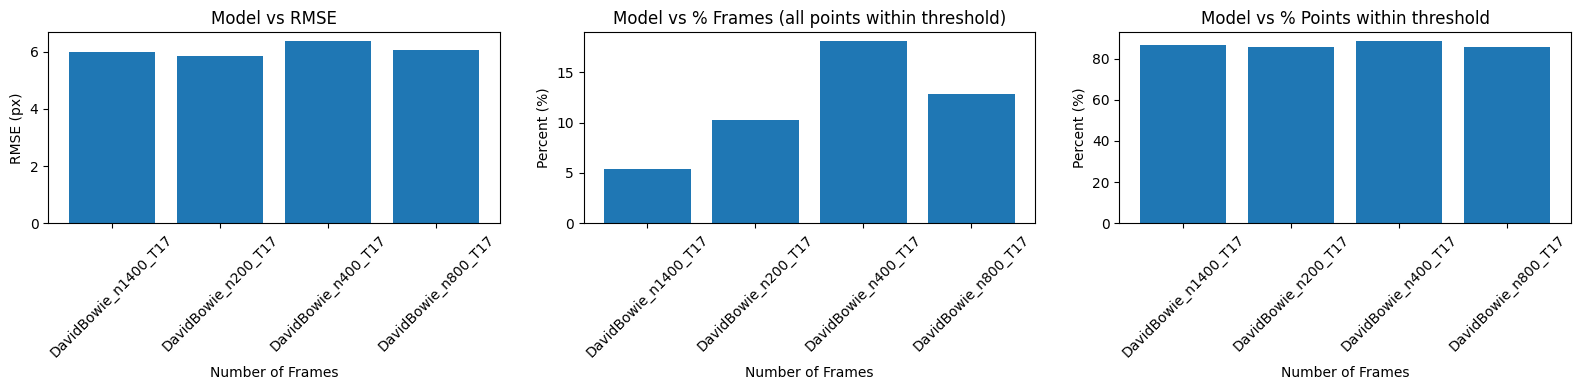

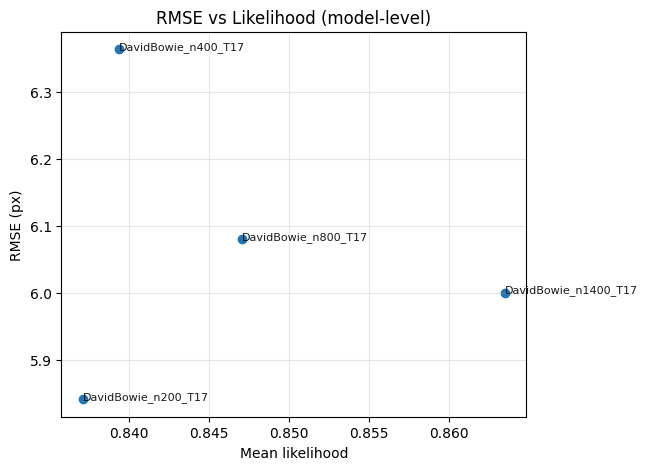

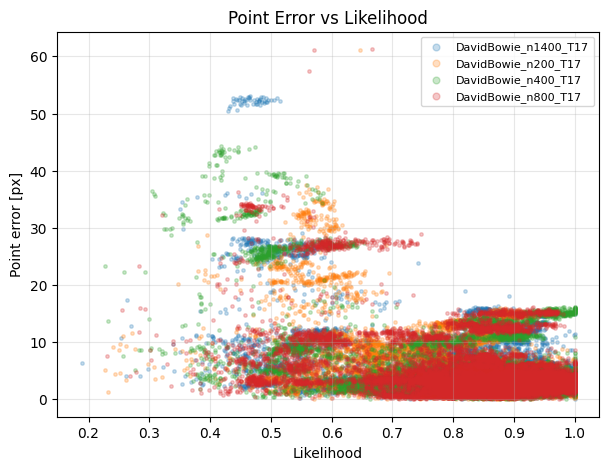

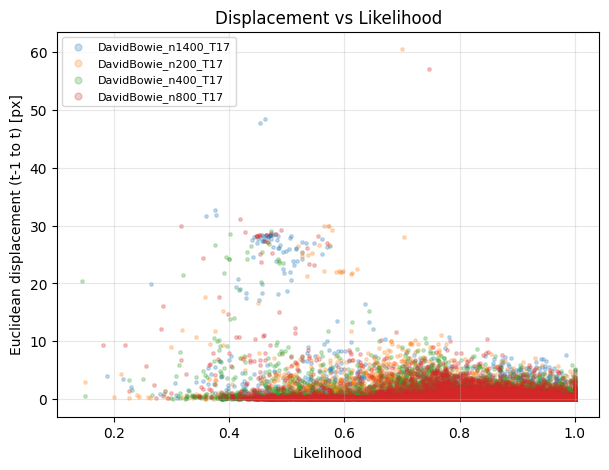

In [185]:
POINT_ERROR_SCATTER_MAX_POINTS = 80000
DISPLACEMENT_SCATTER_MAX_POINTS = 80000
# ----------------------------
# Plots: model type comparisons
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(db_summary_df["model"], db_summary_df["rmse_px"])
axes[0].set_title("Model vs RMSE")
axes[0].set_ylabel("RMSE (px)")
axes[0].set_xlabel("Number of Frames")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(db_summary_df["model"], db_summary_df["percent_frames_all_points_within_threshold"])
axes[1].set_title("Model vs % Frames (all points within threshold)")
axes[1].set_ylabel("Percent (%)")
axes[1].set_xlabel("Number of Frames")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(db_summary_df["model"], db_summary_df["percent_points_within_threshold"])
axes[2].set_title("Model vs % Points within threshold")
axes[2].set_ylabel("Percent (%)")
axes[2].set_xlabel("Number of Frames")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# RMSE vs likelihood (model-level)
plt.figure(figsize=(6, 5))
plt.scatter(db_summary_df["mean_likelihood"], db_summary_df["rmse_px"])
for _, r in db_summary_df.iterrows():
    plt.annotate(r["model"], (r["mean_likelihood"], r["rmse_px"]), fontsize=8, alpha=0.9)
plt.xlabel("Mean likelihood")
plt.ylabel("RMSE (px)")
plt.title("RMSE vs Likelihood (model-level)")
plt.grid(True, alpha=0.3)
plt.show()


# Point-level error vs likelihood
if all_error_rows:
    db_all_error_rows = pd.concat(all_error_rows, ignore_index=True)

    if len(db_all_error_rows) > POINT_ERROR_SCATTER_MAX_POINTS:
        error_plot_df = db_all_error_rows.sample(POINT_ERROR_SCATTER_MAX_POINTS, random_state=42)
    else:
        error_plot_df = db_all_error_rows

    plt.figure(figsize=(7, 5))
    for model_name, g in error_plot_df.groupby("model"):
        plt.scatter(
            g["likelihood"],
            g["distance_px"],
            s=6,
            alpha=0.25,
            label=model_name,
        )
    plt.xlabel("Likelihood")
    plt.ylabel("Point error [px]")
    plt.title("Point Error vs Likelihood")
    plt.legend(markerscale=2, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No point-level error rows available for error-vs-likelihood plot.")


# Euclidean displacement vs likelihood (point-level)
if all_displacement_rows:
    db_all_displacement_rows = pd.concat(all_displacement_rows, ignore_index=True)

    if len(db_all_displacement_rows) > DISPLACEMENT_SCATTER_MAX_POINTS:
        disp_plot_df = db_all_displacement_rows.sample(DISPLACEMENT_SCATTER_MAX_POINTS, random_state=42)
    else:
        disp_plot_df = disp_df

    plt.figure(figsize=(7, 5))
    for model_name, g in disp_plot_df.groupby("model"):
        plt.scatter(
            g["likelihood"],
            g["euclidean_displacement_t-1_to_t"],
            s=6,
            alpha=0.25,
            label=model_name,
        )
    plt.xlabel("Likelihood")
    plt.ylabel("Euclidean displacement (t-1 to t) [px]")
    plt.title("Displacement vs Likelihood")
    plt.legend(markerscale=2, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No displacement rows available for displacement-vs-likelihood plot.")

# Comparing Endive + David Bowie Inner Trial and 2 David Bowie Intra Trial Modeling

In [191]:
# Grabbing all dataframes: errors | summary
david_bowie_errors_path = DAVID_BOWIE_PAIR_ROOT / f"db_cross_trial_errors_{DB_PAIR_SLUG}.csv"
if david_bowie_errors_path.exists():
    db_all_error_rows = pd.read_csv(david_bowie_errors_path)
    db_all_error_rows['Bird'] = 'David Bowie'
    print(f"Loaded all error rows from {david_bowie_errors_path}")
else:
    print(f"Error CSV not found at {david_bowie_errors_path}; db_all_error_rows is not set.")

david_bowie_summary_path = DAVID_BOWIE_PAIR_ROOT / f"db_cross_trial_summary_{DB_PAIR_SLUG}.csv"
if david_bowie_summary_path.exists():
    db_summary_df = pd.read_csv(david_bowie_summary_path)
    db_summary_df['Bird'] = 'David Bowie'
    print(f"Loaded summary dataframe from {david_bowie_summary_path}")
else:
    print(f"Summary CSV not found at {david_bowie_summary_path}; db_summary_df is not set.")


DB_PAIR_SLUG_inv = f"TrainT{DB_EVAL_TRIAL}_EvalT{DB_TRAIN_TRIAL}"
DAVID_BOWIE_PAIR_ROOT_Inv = DAVID_BOWIE_BATCH_ROOT / DB_PAIR_SLUG_inv
david_bowie_errors_path_inv = DAVID_BOWIE_PAIR_ROOT_Inv / f"db_cross_trial_errors_{DB_PAIR_SLUG_inv}.csv"
if david_bowie_errors_path_inv.exists():
    db_all_error_rows_inv = pd.read_csv(david_bowie_errors_path_inv)
    db_all_error_rows_inv['Bird'] = 'David Bowie'
    print(f"Loaded all error rows from {david_bowie_errors_path_inv}")
else:
    print(f"Error CSV not found at {david_bowie_errors_path_inv}; db_all_error_rows_inv is not set.")

david_bowie_summary_path_inv = DAVID_BOWIE_PAIR_ROOT_Inv / f"db_cross_trial_summary_{DB_PAIR_SLUG_inv}.csv"
if david_bowie_summary_path_inv.exists():
    db_summary_df_inv = pd.read_csv(david_bowie_summary_path_inv)
    db_summary_df_inv['Bird'] = 'David Bowie'
    print(f"Loaded summary dataframe from {david_bowie_summary_path_inv}")
else:
    print(f"Summary CSV not found at {david_bowie_summary_path_inv}; db_summary_df_inv is not set.")


DB_PAIR_SLUG_inner = f"Train15_Eval15"
DAVID_BOWIE_PAIR_ROOT_Inner = DAVID_BOWIE_BATCH_ROOT / DB_PAIR_SLUG_inner
david_bowie_errors_path_inner = DAVID_BOWIE_PAIR_ROOT_Inner / f"db_WithinTrial_errors_TrainTest15.csv"
if david_bowie_errors_path_inner.exists():
    db_all_error_rows_inner = pd.read_csv(david_bowie_errors_path_inner)
    db_all_error_rows_inner['Bird'] = 'David Bowie'
    print(f"Loaded all error rows from {david_bowie_errors_path_inner}")
else:
    print(f"Error CSV not found at {david_bowie_errors_path_inner}; db_all_error_rows_inner is not set.")

david_bowie_summary_path_inner = DAVID_BOWIE_PAIR_ROOT_Inner / f"db_WithinTrial_summary_TrainTest15.csv"
if david_bowie_summary_path_inner.exists():
    db_summary_df_inner = pd.read_csv(david_bowie_summary_path_inner)
    db_summary_df_inner['Bird'] = 'David Bowie'
    print(f"Loaded summary dataframe from {david_bowie_summary_path_inner}")
else:
    print(f"Summary CSV not found at {david_bowie_summary_path_inner}; db_summary_df_inner is not set.")



endive_summary_path = ENDIVE_BATCH_ROOT / "end_WithinTrial_summary_TrainTest32.csv"
if endive_summary_path.exists():
    endive_summary_df = pd.read_csv(endive_summary_path)
    endive_summary_df['Bird'] = 'Endive'
    print(f"Loaded Endive summary dataframe from {endive_summary_path}")
else:
    print(f"Endive summary CSV not found at {endive_summary_path}; endive_summary_df is not set.")

endive_errors_path = ENDIVE_BATCH_ROOT / "end_WithinTrial_errors_TrainTest32.csv"
if endive_errors_path.exists():
    endive_error_rows = pd.read_csv(endive_errors_path)
    endive_error_rows['Bird'] = 'Endive'
    print(f"Loaded Endive error rows from {endive_errors_path}")
else:
    print(f"Endive error CSV not found at {endive_errors_path}; endive_error_rows is not set.")




Loaded all error rows from c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15\db_cross_trial_errors_TrainT17_EvalT15.csv
Loaded summary dataframe from c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15\db_cross_trial_summary_TrainT17_EvalT15.csv
Loaded all error rows from c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT15_EvalT17\db_cross_trial_errors_TrainT15_EvalT17.csv
Loaded summary dataframe from c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT15_EvalT17\db_cross_trial_summary_TrainT15_EvalT17.csv
Loaded all error rows from c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\Train15_Eval15\db_With

In [192]:
all_error_df = pd.concat([db_all_error_rows, db_all_error_rows_inv, db_all_error_rows_inner, endive_error_rows], ignore_index=True)
all_summary_df = pd.concat([db_summary_df,db_summary_df_inv, db_summary_df_inner, endive_summary_df], ignore_index=True)
print("Combined David Bowie and Endive summary rows:")
all_summary_df['num_frames'] = all_summary_df['model'].apply(lambda m: (m.split('_')[1]))
display(all_summary_df)
display(all_error_df)



Combined David Bowie and Endive summary rows:


,train_trial,eval_trial,pair,model,rmse_px,threshold_px,percent_frames_all_points_within_threshold,percent_points_within_threshold,mean_likelihood,n_points,Bird,num_frames
0,17,15,TrainT17_EvalT15,DavidBowie_n1400_T17,6.000465,6.000465,5.404498,86.668585,0.863545,125118,David Bowie,n1400
1,17,15,TrainT17_EvalT15,DavidBowie_n200_T17,5.841188,5.841188,10.204767,85.481705,0.837113,125118,David Bowie,n200
2,17,15,TrainT17_EvalT15,DavidBowie_n400_T17,6.364473,6.364473,18.059752,88.307837,0.839376,125118,David Bowie,n400
3,17,15,TrainT17_EvalT15,DavidBowie_n800_T17,6.080534,6.080534,12.856663,85.627168,0.847103,125118,David Bowie,n800
4,15,17,TrainT15_EvalT17,DavidBowie_n200_T15,3.040849,3.040849,0.000000,77.122450,0.874605,64124,David Bowie,n200
5,15,17,TrainT15_EvalT17,DavidBowie_n400_T15,2.825758,2.825758,0.000000,71.144969,0.880093,64124,David Bowie,n400
6,15,17,TrainT15_EvalT17,DavidBowie_n800_T15,2.935273,2.935273,1.768173,75.877986,0.884774,64124,David Bowie,n800
7,15,15,Train15_Eval15,DavidBowie_n200_T15,0.875024,0.875024,98.577982,99.915902,0.962813,91560,David Bowie,n200
8,15,15,Train15_Eval15,DavidBowie_n400_T15,0.531432,0.531432,99.816514,99.995631,0.957522,91560,David Bowie,n400
9,15,15,Train15_Eval15,DavidBowie_n800_T15,0.589323,0.589323,99.770642,99.994539,0.965509,91560,David Bowie,n800


,model,camera,bodypart,frame_id,distance_px,likelihood,pair,train_trial,eval_trial,Bird
0,DavidBowie_n1400_T17,cam1,Cranium_Left_Anterior,1,3.516401,0.988786,TrainT17_EvalT15,17.0,15.0,David Bowie
1,DavidBowie_n1400_T17,cam1,Cranium_Left_Anterior,2,3.520267,0.987512,TrainT17_EvalT15,17.0,15.0,David Bowie
2,DavidBowie_n1400_T17,cam1,Cranium_Left_Anterior,3,3.593619,0.990753,TrainT17_EvalT15,17.0,15.0,David Bowie
3,DavidBowie_n1400_T17,cam1,Cranium_Left_Anterior,4,3.733563,0.989375,TrainT17_EvalT15,17.0,15.0,David Bowie
4,DavidBowie_n1400_T17,cam1,Cranium_Left_Anterior,5,3.540931,0.988667,TrainT17_EvalT15,17.0,15.0,David Bowie
...,...,...,...,...,...,...,...,...,...,...
1407199,Endive_n800_T32,cam2,Maxilla_Marker_Right_Anterior,3683,0.525688,0.977788,Train32_Eval32,32.0,32.0,Endive
1407200,Endive_n800_T32,cam2,Maxilla_Marker_Right_Anterior,3686,0.291126,0.979665,Train32_Eval32,32.0,32.0,Endive
1407201,Endive_n800_T32,cam2,Maxilla_Marker_Right_Anterior,3688,0.546176,0.975573,Train32_Eval32,32.0,32.0,Endive
1407202,Endive_n800_T32,cam2,Maxilla_Marker_Right_Anterior,3689,0.441174,0.979705,Train32_Eval32,32.0,32.0,Endive


,model,camera,bodypart,frame_id,distance_px,likelihood,pair,train_trial,eval_trial
482123,DavidBowie_n800_T17,cam2,Keel_Dorsal_Anterior,2505,1.821258,0.945907,TrainT17_EvalT15,17,15
476084,DavidBowie_n800_T17,cam2,Glottis,2424,1.293432,0.808504,TrainT17_EvalT15,17,15
86666,DavidBowie_n1400_T17,cam2,Beak_Maxilla_Right_Posterior,276,1.834491,0.843118,TrainT17_EvalT15,17,15
333182,DavidBowie_n400_T17,cam2,Beak_Mandible_Right_Anterior,2514,3.035798,0.995021,TrainT17_EvalT15,17,15
397080,DavidBowie_n800_T17,cam1,Beak_Maxilla_Right_Anterior,874,4.320963,0.872752,TrainT17_EvalT15,17,15
...,...,...,...,...,...,...,...,...,...
169646,DavidBowie_n200_T17,cam1,Keel_Dorsal_Anterior,2823,2.376408,0.769788,TrainT17_EvalT15,17,15
364784,DavidBowie_n400_T17,cam2,Pelvis_Right_Inferior,1347,1.733873,0.873420,TrainT17_EvalT15,17,15
473134,DavidBowie_n800_T17,cam2,Tongue_Lower_Palette,2453,1.818665,0.934513,TrainT17_EvalT15,17,15
96158,DavidBowie_n1400_T17,cam2,Tongue_Lower_Palette,831,2.031055,0.980588,TrainT17_EvalT15,17,15


In [193]:
combined_analysis_route = DEEPLABCUT_ROOT / "DB_END_COMBINED_EVAL"
summary_out = combined_analysis_route / "combined_summary.csv"
error_out = combined_analysis_route / "combined_errors.csv"
all_summary_df.to_csv(summary_out, index=False)
all_error_df.to_csv(error_out, index=False)


Saved model comparison bar plot to c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL\model_comparison_bars.png


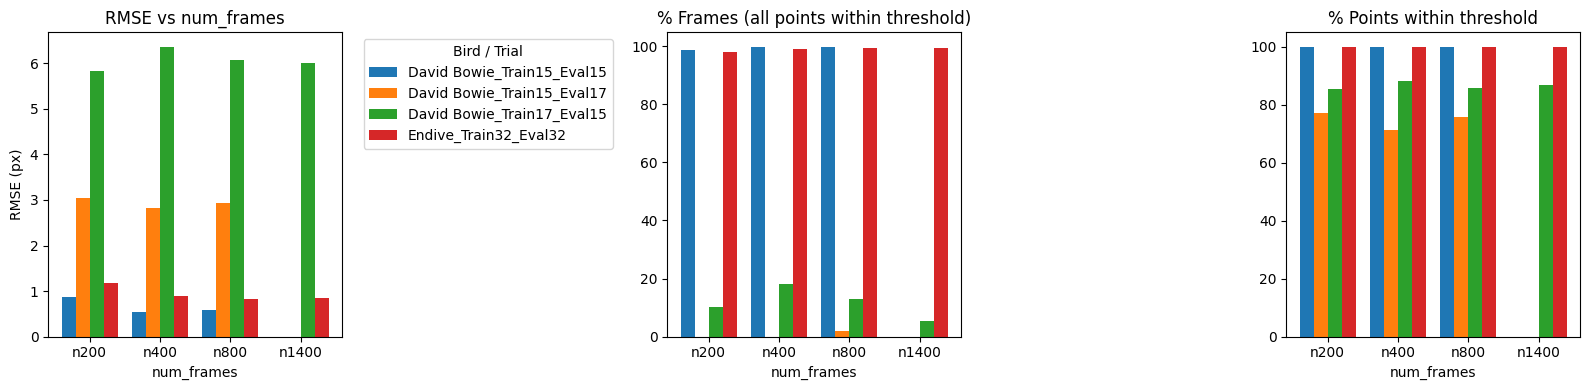

Saved RMSE vs Likelihood plot to c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL\rmse_vs_likelihood.png


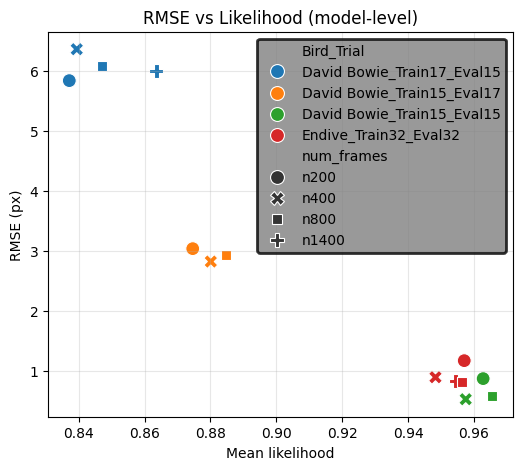

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_82312\39671455.py:146: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


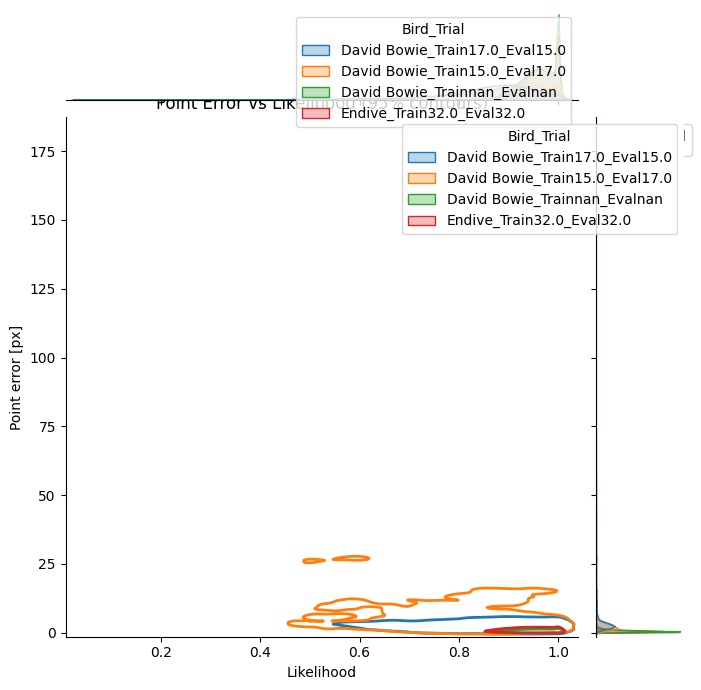

In [196]:

# ----------------------------
# Plots: model type comparisons
# ----------------------------

#change ordering of model to be [n200, n400, n800, n1400]
frame_order = ['n200', 'n400', 'n800', 'n1400']
all_summary_df['num_frames'] = pd.Categorical(all_summary_df['num_frames'], categories=frame_order, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Create combined label
df = all_summary_df.copy()
df["Bird_Trial"] = df["Bird"].astype(str) + "_Train" + df["train_trial"].astype(str) + "_Eval" + df["eval_trial"].astype(str)

frames = frame_order
groups = sorted(df["Bird_Trial"].unique())

x = np.arange(len(frames))
bar_width = 0.8 / max(len(groups), 1)

for i, group in enumerate(groups):
    s = (
        df[df["Bird_Trial"] == group]
        .set_index("num_frames")
        .reindex(frames)
    )
    
    offset = (i - (len(groups) - 1) / 2) * bar_width
    
    axes[0].bar(x + offset, s["rmse_px"], width=bar_width, label=group)
    axes[1].bar(x + offset, s["percent_frames_all_points_within_threshold"], width=bar_width)
    axes[2].bar(x + offset, s["percent_points_within_threshold"], width=bar_width)

# Formatting
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(frames)
    ax.set_xlabel("num_frames")

axes[0].set_title("RMSE vs num_frames")
axes[0].set_ylabel("RMSE (px)")

axes[1].set_title("% Frames (all points within threshold)")
axes[2].set_title("% Points within threshold")

axes[0].legend(title="Bird / Trial", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
save_path = combined_analysis_route / "model_comparison_bars.png"
plt.savefig(save_path, bbox_inches='tight')
print(f"Saved model comparison bar plot to {save_path}")
plt.show()



#---------------------------------------------------------------------------------------------------#
# RMSE vs likelihood (model-level)
plt.figure(figsize=(6, 5))

marker_map = {'n200': '+', 'n400': 's', 'n800': '^', 'n1400': 'D'}

# for bird_trial, g in df.groupby("Bird_Trial"):
#     for nf, subg in g.groupby("num_frames"):
#         plt.scatter(
#             subg["mean_likelihood"],
#             subg["rmse_px"],
#             label=bird_trial,
#             alpha=0.85,
#             marker=marker_map.get(nf, 'o')
#         )
sns.scatterplot(
    data=df,
    x="mean_likelihood",
    y="rmse_px",
    hue="Bird_Trial",
    style="num_frames",
    s=100,
)


plt.xlabel("Mean likelihood")
plt.ylabel("RMSE (px)")
plt.title("RMSE vs Likelihood (model-level)")
plt.legend(title="Bird")
legend = plt.legend(frameon = 1)
frame = legend.get_frame()
frame.set_facecolor('grey')
frame.set_edgecolor('black')
frame.set_linewidth(2)
plt.grid(True, alpha=0.3)
save_path = combined_analysis_route / "rmse_vs_likelihood.png"
plt.savefig(save_path, bbox_inches='tight')
print(f"Saved RMSE vs Likelihood plot to {save_path}")
plt.show()  





#---------------------------------------------------------------------------------------------------#
# Point-level error vs likelihood
error_plot_df = all_error_df.copy()
error_plot_df['Bird_Trial'] = error_plot_df["Bird"].astype(str) + "_Train" + error_plot_df["train_trial"].astype(str) + "_Eval" + error_plot_df["eval_trial"].astype(str)
g = sns.JointGrid(
    data=error_plot_df,
    x="likelihood",
    y="distance_px",
    height=7
)

# --- Main panel: 95% contours (no fill → hollow ovals)
for bird_trial, df_sub in error_plot_df.groupby("Bird_Trial"):
    sns.kdeplot(
        data=df_sub,
        x="likelihood",
        y="distance_px",
        ax=g.ax_joint,
        levels=[0.05],   # ~95% contour
        fill=False,
        linewidths=2,
        label=bird_trial
    )

# --- Marginals (top + right)
sns.kdeplot(
    data=error_plot_df,
    x="likelihood",
    hue="Bird_Trial",
    ax=g.ax_marg_x,
    fill=True,
    alpha=0.3,
    common_norm=False
)

sns.kdeplot(
    data=error_plot_df,
    y="distance_px",
    hue="Bird_Trial",
    ax=g.ax_marg_y,
    fill=True,
    alpha=0.3,
    common_norm=False
)

# Labels
g.ax_joint.set_xlabel("Likelihood")
g.ax_joint.set_ylabel("Point error [px]")
g.ax_joint.set_title("Point Error vs Likelihood (95% contours)")

g.ax_joint.legend(title="Bird / Trial", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(save_path, bbox_inches='tight')
plt.show()

# if len(all_error_df) > POINT_ERROR_SCATTER_MAX_POINTS:
#     error_plot_df = all_error_df.sample(POINT_ERROR_SCATTER_MAX_POINTS, random_state=42)
# else:
#     error_plot_df = all_error_df.copy()
# error_plot_df['Bird_Trial'] = error_plot_df['model'].apply(lambda m: (m.split('_')[0]  + m.split('_')[2]))
# plt.figure(figsize=(7, 5))
# for bird_trial, g in error_plot_df.groupby("Bird_Trial"):
#     plt.scatter(
#             g["likelihood"],
#             g["distance_px"],
#             s=10,
#             alpha=0.1,
#             label=bird_trial,
#         )
# plt.xlabel("Likelihood")
# plt.ylabel("Point error [px]")
# plt.title("Point Error vs Likelihood")
# plt.legend(markerscale=2, fontsize=8)
# plt.grid(True, alpha=0.3)
# save_path = combined_analysis_route / "point_error_vs_likelihood.png"
# plt.savefig(save_path, bbox_inches='tight')
# print(f"Saved Point Error vs Likelihood plot to {save_path}")
# plt.show()


# # Euclidean displacement vs likelihood (point-level)
# if all_displacement_rows:
#     db_all_displacement_rows = pd.concat(all_displacement_rows, ignore_index=True)

#     if len(db_all_displacement_rows) > DISPLACEMENT_SCATTER_MAX_POINTS:
#         disp_plot_df = db_all_displacement_rows.sample(DISPLACEMENT_SCATTER_MAX_POINTS, random_state=42)
#     else:
#         disp_plot_df = disp_df

#     plt.figure(figsize=(7, 5))
#     for model_name, g in disp_plot_df.groupby("model"):
#         plt.scatter(
#             g["likelihood"],
#             g["euclidean_displacement_t-1_to_t"],
#             s=6,
#             alpha=0.1,
#             label=model_name,
#         )
#     plt.xlabel("Likelihood")
#     plt.ylabel("Euclidean displacement (t-1 to t) [px]")
#     plt.title("Displacement vs Likelihood")
#     plt.legend(markerscale=2, fontsize=8)
#     plt.grid(True, alpha=0.3)
#     plt.show()
# else:
#     print("No displacement rows available for displacement-vs-likelihood plot.")



### Send Predicted Data Back to XMALab Format

In [ ]:
import re
from pathlib import Path

import xrommtools as xt

# ----------------------------
# Export DLC predictions to XMALab format
# ----------------------------
OVERWRITE_XMA = False
STRICT_MODEL_NAME = True

# Run for all bird folders found under DEEPLABCUT_ROOT.
bird_roots = sorted([p for p in DEEPLABCUT_ROOT.iterdir() if p.is_dir()])

pair_name_re = re.compile(r"^TrainT(?P<train>\d+)_EvalT(?P<eval>\d+)$")


def infer_camera_tag(path: Path) -> str | None:
    text = path.stem.lower()
    if "cam2" in text:
            return "cam2"
    elif "cam1" in text:
        return "cam1"
    return None


def normalize_pair_key(path: Path) -> str:
    key = path.stem.lower()

    # Handle names like uf_cam1DLC... and uf_cam2DLC...
    key = key.replace("cam1", "camx")
    key = key.replace("cam2", "camx")

    # Optional fallback for tokenized c1/c2 markers only.
    key = re.sub(r"(?<![a-z0-9])c1(?![a-z0-9])", "cx", key)
    key = re.sub(r"(?<![a-z0-9])c2(?![a-z0-9])", "cx", key)

    key = re.sub(r"[^a-z0-9]+", "_", key).strip("_")
    return key or "pair"


rows: list[dict[str, object]] = []
converted = 0
skipped = 0
failed = 0

for bird_root in bird_roots:
    bird = bird_root.name
    if bird.lower() not in {"endive", "davidbowie"}:
        continue
    bird_batch_root = bird_root / "ExperimentEval" / "UFBatch"

    if not bird_batch_root.exists():
        continue

    pair_dirs = sorted([p for p in bird_batch_root.iterdir() if p.is_dir() and pair_name_re.match(p.name)])
    if not pair_dirs:
        continue

    for pair_dir in pair_dirs:
        match = pair_name_re.match(pair_dir.name)
        if match is None:
            continue

        train_trial = int(match.group("train"))
        eval_trial = int(match.group("eval"))

        output_root = bird_root / "XMA_Predictions" / f"EvalT{eval_trial}" / f"TrainT{train_trial}"
        output_root.mkdir(parents=True, exist_ok=True)

        model_dirs = sorted([p for p in pair_dir.iterdir() if p.is_dir()])
        model_name_re = re.compile(rf"^{re.escape(bird)}_n\d+_T{train_trial}$")

        for model_dir in model_dirs:
            if STRICT_MODEL_NAME and model_name_re.match(model_dir.name) is None:
                rows.append(
                    {
                        "bird": bird,
                        "train_trial": train_trial,
                        "eval_trial": eval_trial,
                        "model_dir": model_dir.name,
                        "pair_key": None,
                        "cam1_csv": None,
                        "cam2_csv": None,
                        "output_dir": str(output_root),
                        "status": "skipped_model_name",
                        "error": "Model folder does not match expected pattern.",
                    }
                )
                skipped += 1
                continue

            pred_csvs = sorted(model_dir.glob("*DLC*.csv"))
            if not pred_csvs:
                rows.append(
                    {
                        "bird": bird,
                        "train_trial": train_trial,
                        "eval_trial": eval_trial,
                        "model_dir": model_dir.name,
                        "pair_key": None,
                        "cam1_csv": None,
                        "cam2_csv": None,
                        "output_dir": str(output_root),
                        "status": "skipped_no_csv",
                        "error": "No *DLC*.csv files found.",
                    }
                )
                skipped += 1
                continue

            cam1_map: dict[str, Path] = {}
            cam2_map: dict[str, Path] = {}
            unknown_csvs: list[Path] = []

            
            for csv_path in pred_csvs:
                
                cam = infer_camera_tag(csv_path)
                key = normalize_pair_key(csv_path)
                if cam == "cam1":
                    cam1_map.setdefault(key, csv_path)
                elif cam == "cam2":
                    cam2_map.setdefault(key, csv_path)
                else:
                    unknown_csvs.append(csv_path)

            for u in unknown_csvs:
                rows.append(
                    {
                        "bird": bird,
                        "train_trial": train_trial,
                        "eval_trial": eval_trial,
                        "model_dir": model_dir.name,
                        "pair_key": None,
                        "cam1_csv": str(u),
                        "cam2_csv": None,
                        "output_dir": str(output_root),
                        "status": "skipped_unknown_camera",
                        "error": "Could not infer camera tag from filename.",
                    }
                )
                skipped += 1

            pair_keys = sorted(set(cam1_map).intersection(cam2_map))
            missing_keys = sorted((set(cam1_map) ^ set(cam2_map)))

            for mkey in missing_keys:
                rows.append(
                    {
                        "bird": bird,
                        "train_trial": train_trial,
                        "eval_trial": eval_trial,
                        "model_dir": model_dir.name,
                        "pair_key": mkey,
                        "cam1_csv": str(cam1_map[mkey]) if mkey in cam1_map else None,
                        "cam2_csv": str(cam2_map[mkey]) if mkey in cam2_map else None,
                        "output_dir": str(output_root),
                        "status": "skipped_unpaired_camera",
                        "error": "Missing matching cam1/cam2 CSV.",
                    }
                )
                skipped += 1

            for pair_key in pair_keys:
                cam1_csv = cam1_map[pair_key]
                cam2_csv = cam2_map[pair_key]
                trialname = f"{model_dir.name}__{pair_key}"
                out_csv = output_root / f"{trialname}-Predicted2DPoints.csv"
                out_h5 = output_root / f"{trialname}-Predicted2DPoints.h5"

                if (out_csv.exists() or out_h5.exists()) and not OVERWRITE_XMA:
                    rows.append(
                        {
                            "bird": bird,
                            "train_trial": train_trial,
                            "eval_trial": eval_trial,
                            "model_dir": model_dir.name,
                            "pair_key": pair_key,
                            "cam1_csv": str(cam1_csv),
                            "cam2_csv": str(cam2_csv),
                            "output_dir": str(output_root),
                            "status": "skipped_exists",
                            "error": "Output exists and OVERWRITE_XMA is False.",
                        }
                    )
                    skipped += 1
                    continue

                try:
                    xt.dlc_to_xma(str(cam1_csv), str(cam2_csv), trialname, str(output_root))
                    rows.append(
                        {
                            "bird": bird,
                            "train_trial": train_trial,
                            "eval_trial": eval_trial,
                            "model_dir": model_dir.name,
                            "pair_key": pair_key,
                            "cam1_csv": str(cam1_csv),
                            "cam2_csv": str(cam2_csv),
                            "output_dir": str(output_root),
                            "status": "converted",
                            "error": None,
                        }
                    )
                    converted += 1
                except Exception as exc:
                    rows.append(
                        {
                            "bird": bird,
                            "train_trial": train_trial,
                            "eval_trial": eval_trial,
                            "model_dir": model_dir.name,
                            "pair_key": pair_key,
                            "cam1_csv": str(cam1_csv),
                            "cam2_csv": str(cam2_csv),
                            "output_dir": str(output_root),
                            "status": "failed",
                            "error": str(exc),
                        }
                    )
                    failed += 1

xma_export_df = pd.DataFrame(rows)
if xma_export_df.empty:
    print("No eligible prediction CSV pairs were found under any bird UFBatch TrainT*_EvalT* folders.")
else:
    display(xma_export_df)

print(f"XMALab export summary | converted={converted} | skipped={skipped} | failed={failed}")

[WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT15_EvalT15/DavidBowie_n200_T15/uf_cam1DLC_Resnet50_CanariApr24shuffle1_snapshot_200.csv'), WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT15_EvalT15/DavidBowie_n200_T15/uf_cam2DLC_Resnet50_CanariApr24shuffle1_snapshot_200.csv')]
Processing CSV: uf_cam1DLC_Resnet50_CanariApr24shuffle1_snapshot_200.csv
Processing CSV: uf_cam2DLC_Resnet50_CanariApr24shuffle1_snapshot_200.csv
[WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT15_EvalT15/DavidBowie_n400_T15/uf_cam1DLC_Resnet50_CanariApr24shuffle1_snapshot_200.csv'), WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT15_EvalT15/DavidBowie_n400_

c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\xrommtools.py:322: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Cranium_Left_Anterior_cam1_X', 'Cranium_Left_Anterior_cam1_Y',
       'Cranium_Left_Anterior_cam2_X', 'Cranium_Left_Anterior_cam2_Y',
       'Cranium_Left_Middle_cam1_X', 'Cranium_Left_Middle_cam1_Y',
       'Cranium_Left_Middle_cam2_X', 'Cranium_Left_Middle_cam2_Y',
       'Cranium_Right_Middle_cam1_X', 'Cranium_Right_Middle_cam1_Y',
       'Cranium_Right_Middle_cam2_X', 'Cranium_Right_Middle_cam2_Y',
       'Cranium_Right_Posterior_cam1_X', 'Cranium_Right_Posterior_cam1_Y',
       'Cranium_Right_Posterior_cam2_X', 'Cranium_Right_Posterior_cam2_Y',
       'Beak_Mandible_Left_Posterior_cam1_X',
       'Beak_Mandible_Left_Posterior_cam1_Y',
       'Beak_Mandible_Left_Posterior_cam2_X',
       'Beak_Mand

[WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT15_EvalT17/DavidBowie_n800_T15/db_cam1_T17DLC_Resnet50_CanariApr24shuffle1_snapshot_200.csv'), WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT15_EvalT17/DavidBowie_n800_T15/db_cam2_T17DLC_Resnet50_CanariApr24shuffle1_snapshot_200.csv')]
Processing CSV: db_cam1_T17DLC_Resnet50_CanariApr24shuffle1_snapshot_200.csv
Processing CSV: db_cam2_T17DLC_Resnet50_CanariApr24shuffle1_snapshot_200.csv
[WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT17_EvalT15/DavidBowie_n1400_T17/db_cam1_T15DLC_Resnet50_CanariApr22shuffle1_snapshot_200.csv'), WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT17_Eva

c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\xrommtools.py:322: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Cranium_Left_Anterior_cam1_X', 'Cranium_Left_Anterior_cam1_Y',
       'Cranium_Left_Anterior_cam2_X', 'Cranium_Left_Anterior_cam2_Y',
       'Cranium_Left_Middle_cam1_X', 'Cranium_Left_Middle_cam1_Y',
       'Cranium_Left_Middle_cam2_X', 'Cranium_Left_Middle_cam2_Y',
       'Cranium_Right_Middle_cam1_X', 'Cranium_Right_Middle_cam1_Y',
       'Cranium_Right_Middle_cam2_X', 'Cranium_Right_Middle_cam2_Y',
       'Cranium_Right_Posterior_cam1_X', 'Cranium_Right_Posterior_cam1_Y',
       'Cranium_Right_Posterior_cam2_X', 'Cranium_Right_Posterior_cam2_Y',
       'Beak_Mandible_Left_Posterior_cam1_X',
       'Beak_Mandible_Left_Posterior_cam1_Y',
       'Beak_Mandible_Left_Posterior_cam2_X',
       'Beak_Mand

[WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT17_EvalT15/DavidBowie_n200_T17/db_cam1_T15DLC_Resnet50_CanariApr22shuffle1_snapshot_200.csv'), WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT17_EvalT15/DavidBowie_n200_T17/db_cam2_T15DLC_Resnet50_CanariApr22shuffle1_snapshot_200.csv')]
Processing CSV: db_cam1_T15DLC_Resnet50_CanariApr22shuffle1_snapshot_200.csv
Processing CSV: db_cam2_T15DLC_Resnet50_CanariApr22shuffle1_snapshot_200.csv
[WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT17_EvalT15/DavidBowie_n400_T17/db_cam1_T15DLC_Resnet50_CanariApr22shuffle1_snapshot_200.csv'), WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT17_Eval

,bird,train_trial,eval_trial,model_dir,pair_key,cam1_csv,cam2_csv,output_dir,status,error
0,DavidBowie,15,15,DavidBowie_n200_T15,uf_camxdlc_resnet50_canariapr24shuffle1_snapsh...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,converted,None
1,DavidBowie,15,15,DavidBowie_n400_T15,uf_camxdlc_resnet50_canariapr24shuffle1_snapsh...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,converted,None
2,DavidBowie,15,15,DavidBowie_n800_T15,uf_camxdlc_resnet50_canariapr24shuffle1_snapsh...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,converted,None
3,DavidBowie,15,17,DavidBowie_n200_T15,db_camx_t17dlc_resnet50_canariapr24shuffle1_sn...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,converted,None
4,DavidBowie,15,17,DavidBowie_n400_T15,db_camx_t17dlc_resnet50_canariapr24shuffle1_sn...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,converted,None
5,DavidBowie,15,17,DavidBowie_n800_T15,db_camx_t17dlc_resnet50_canariapr24shuffle1_sn...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,converted,None
6,DavidBowie,15,17,sv,None,None,None,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_model_name,Model folder does not match expected pattern.
7,DavidBowie,17,15,DavidBowie_n1400_T17,db_camx_t15dlc_resnet50_canariapr22shuffle1_sn...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,converted,None
8,DavidBowie,17,15,DavidBowie_n200_T17,db_camx_t15dlc_resnet50_canariapr22shuffle1_sn...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,converted,None
9,DavidBowie,17,15,DavidBowie_n400_T17,db_camx_t15dlc_resnet50_canariapr22shuffle1_sn...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,converted,None


XMALab export summary | converted=10 | skipped=6 | failed=0


In [216]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

# ----------------------------
# One-off test target
# ----------------------------
EXAMPLE_BIRD_ROOT = DEEPLABCUT_ROOT / "DavidBowie"
EXAMPLE_EVAL_TRIAL = 17
EXAMPLE_TRAIN_TRIAL = 15

EXAMPLE_CSV = Path(
    EXAMPLE_BIRD_ROOT / "XMA_Predictions/EvalT17/TrainT15/DavidBowie_n200_T15__db_camx_t17dlc_resnet50_canariapr24shuffle1_snapshot_200-Predicted2DPoints.csv"
)
EXAMPLE_H5 = EXAMPLE_CSV.with_suffix(".h5")


def _resolve_eval_image_dir(bird_root: Path, eval_trial: int, cam_idx: int) -> Path | None:
    base = bird_root / f"TrainingData_T{eval_trial}"
    direct = base / f"Cam{cam_idx}_Img00UND_Trial{eval_trial}"
    if direct.exists():
        return direct
    if base.exists():
        matches = sorted(base.rglob(f"Cam{cam_idx}_Img00UND_Trial{eval_trial}"))
        if matches:
            return matches[0]
    return None


def _infer_nan_pad_rows_from_eval_images(bird_root: Path, eval_trial: int) -> int:
    # Prefer cam1; fallback to cam2.
    for cam_idx in (1, 2):
        img_dir = _resolve_eval_image_dir(bird_root, eval_trial, cam_idx)
        if img_dir is None:
            continue

        image_files = [
            p for p in img_dir.iterdir()
            if p.is_file() and p.suffix.lower() in {".tif", ".tiff", ".jpg", ".jpeg", ".png", ".bmp"}
        ]
        nums = []
        for p in image_files:
            # IMPORTANT: case-insensitive via lower(); look for UND.{num}.ext
            m = re.search(r"und\.(\d+)\.(tif|tiff|jpg|jpeg|png|bmp)$", p.name.lower())
            if m is not None:
                nums.append(int(m.group(1)))

        if nums:
            return min(nums)-1

    return 0


def _prepend_nan_rows_to_xma_outputs(csv_path: Path, h5_path: Path, pad_rows: int) -> bool:
    if pad_rows <= 0:
        return False
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing CSV: {csv_path}")

    df = pd.read_csv(csv_path)

    # Idempotent: do not pad twice.
    check_n = min(pad_rows, len(df))
    if check_n > 0 and df.iloc[:check_n].isna().all(axis=None):
        return False

    pad_df = pd.DataFrame(np.nan, index=range(pad_rows), columns=df.columns)
    padded_df = pd.concat([pad_df, df], ignore_index=True)
    padded_df.to_csv(csv_path, index=False)

    if h5_path.exists():
        try:
            h5_df = pd.read_hdf(h5_path, key="df_with_missing")
        except Exception:
            h5_df = pd.read_hdf(h5_path)
        pad_h5 = pd.DataFrame(np.nan, index=range(pad_rows), columns=h5_df.columns)
        h5_padded = pd.concat([pad_h5, h5_df], ignore_index=True)
        h5_padded.to_hdf(h5_path, key="df_with_missing", mode="w")

    return True


if not EXAMPLE_CSV.exists():
    raise FileNotFoundError(f"Example CSV not found: {EXAMPLE_CSV}")

pad_rows = _infer_nan_pad_rows_from_eval_images(EXAMPLE_BIRD_ROOT, EXAMPLE_EVAL_TRIAL)
did_pad = _prepend_nan_rows_to_xma_outputs(EXAMPLE_CSV, EXAMPLE_H5, pad_rows)

print(f"Pad rows inferred from EvalT{EXAMPLE_EVAL_TRIAL} image names: {pad_rows}")
print(f"Padded now: {did_pad}")
print(f"CSV: {EXAMPLE_CSV}")
print(f"H5 exists: {EXAMPLE_H5.exists()}")

# Quick validation: first pad_rows should all be NaN if padding happened earlier or now.
if pad_rows > 0:
    check_df = pd.read_csv(EXAMPLE_CSV, nrows=pad_rows)
    print(f"Top {pad_rows} rows all NaN: {check_df.isna().all(axis=None)}")

Pad rows inferred from EvalT17 image names: 3538
Padded now: True
CSV: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\XMA_Predictions\EvalT17\TrainT15\DavidBowie_n200_T15__db_camx_t17dlc_resnet50_canariapr24shuffle1_snapshot_200-Predicted2DPoints.csv
H5 exists: True
Top 3538 rows all NaN: True


C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_82312\3283231119.py:80: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Cranium_Left_Anterior_cam1_X', 'Cranium_Left_Anterior_cam1_Y',
       'Cranium_Left_Anterior_cam2_X', 'Cranium_Left_Anterior_cam2_Y',
       'Cranium_Left_Middle_cam1_X', 'Cranium_Left_Middle_cam1_Y',
       'Cranium_Left_Middle_cam2_X', 'Cranium_Left_Middle_cam2_Y',
       'Cranium_Right_Middle_cam1_X', 'Cranium_Right_Middle_cam1_Y',
       'Cranium_Right_Middle_cam2_X', 'Cranium_Right_Middle_cam2_Y',
       'Cranium_Right_Posterior_cam1_X', 'Cranium_Right_Posterior_cam1_Y',
       'Cranium_Right_Posterior_cam2_X', 'Cranium_Right_Posterior_cam2_Y',
       'Beak_Mandible_Left_Posterior_cam1_X',
       'Beak_Mandible_Left_Posterior_cam1_Y',
       'Beak_Mandible_Left_Posterior_cam2_X',
       'Beak_Mandible_Left_Posterior_cam2_Y',

In [ ]:
train_eval_pairs = [
    (15, 17),
    (17, 15),
    (15, 15),  # within-trial for Trial 15
    (32, 32),  # within-trial for Trial 32]
DAVID_BOWIE_BATCH_ROOT 

In [108]:
# 2x4 panel: plot-likelihood PNGs for DavidBowie (row 1) and Endive (row 2)

# birds = ["DavidBowie", "Endive"]

# def model_sort_key(name: str):
#     m = re.search(r"(\d+)$", name)
#     return int(m.group(1)) if m else float("inf")

# # Discover model names from both birds, then keep first 4 in numeric order
# all_models = set()
# for bird in birds:
#     batch_root = DEEPLABCUT_ROOT / bird / "ExperimentEval" / "UFBatch"
#     if batch_root.exists():
#         all_models.update([p.name for p in batch_root.iterdir() if p.is_dir() and p.name.startswith("n")])

# model_order = sorted(all_models, key=model_sort_key)[:4]

# # Collect one plot-likelihood PNG per (bird, model), preferring cam1/uf_cam1/db_cam1
# likelihood_plots = {}
# for bird in birds:
#     batch_root = DEEPLABCUT_ROOT / bird / "ExperimentEval" / "UFBatch"
#     for model in model_order:
#         model_dir = batch_root / model
#         if not model_dir.exists():
#             continue

#         preferred = sorted(model_dir.glob("plot-poses/*cam1*/plot-likelihood*.png"))
#         if not preferred:
#             preferred = sorted(model_dir.glob("plot-poses/*/plot-likelihood*.png"))

#         if preferred:
#             likelihood_plots[(bird, model)] = preferred[0]

# # Draw fixed 2x4 grid
# fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# for r, bird in enumerate(birds):
#     for c in range(4):
#         ax = axes[r, c]
#         model = model_order[c] if c < len(model_order) else f"slot_{c+1}"
#         png_path = likelihood_plots.get((bird, model))

#         if png_path is not None and png_path.exists():
#             img = plt.imread(str(png_path))
#             ax.imshow(img)
#             ax.set_title(f"{bird} | {model}", fontsize=10)
#             ax.axis("off")
#         else:
#             ax.text(0.5, 0.5, f"Missing\n{bird} | {model}", ha="center", va="center", fontsize=10)
#             ax.set_xticks([])
#             ax.set_yticks([])
#             ax.set_frame_on(True)

# plt.suptitle("Plot-likelihood per model (DavidBowie vs Endive)", fontsize=14, y=1.02)
# plt.tight_layout()
# plt.show()
# plt.savefig(DEEPLABCUT_ROOT / "DavidBowie_vs_Endive_plot-likelihood_comparison.png", dpi=300, bbox_inches="tight")

In [ ]:
# # Save first, then show
# out_path = DEEPLABCUT_ROOT / "DavidBowie_vs_Endive_plot-likelihood_comparison.png"
# out_path.parent.mkdir(parents=True, exist_ok=True)

# fig.savefig(out_path, dpi=300, bbox_inches="tight")
# print(f"Saved: {out_path.resolve()}")

# plt.show()

Saved: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie_vs_Endive_plot-likelihood_comparison.png


## David Bowie UFBatch Figure Reproduction (4 models x 2 cameras)

This section reproduces the FigureForCJSM-style overlay figure for the new UFBatch outputs in `ExperimentEval/UFBatch/DavidBowie_n{frames}` and adds an interactive widget to control:
- frame overlay alpha
- minimum prediction likelihood threshold

In [109]:
import matplotlib.font_manager as font_manager
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.lines import Line2D
import ipywidgets as widgets
from IPython.display import display


def update_font(handle, orig):
    handle.update_from(orig)
    handle.set_linewidth(8)


def draw_in_image_title(ax, cam_label, details, y_top=130, y_bottom=151, x_center=397):
    ax.text(
        x_center,
        y_top,
        cam_label,
        ha="center",
        va="center",
        color="white",
        fontsize=20,
        fontweight="bold",
        bbox=dict(facecolor="black", alpha=0.7, edgecolor="none", pad=2),
    )
    ax.text(
        x_center,
        y_bottom,
        details,
        ha="center",
        va="center",
        color="white",
        fontsize=18,
        fontweight="normal",
        bbox=dict(facecolor="black", alpha=0.7, edgecolor="none", pad=2),
    )


def parse_truth_cam(truth_df, cam_tag):
    cols = [c for c in truth_df.columns if f"_{cam_tag}_" in c]
    tmp = truth_df[cols].copy().reset_index(names="frame")

    long = tmp.melt(id_vars="frame", var_name="col", value_name="val")
    parts = long["col"].str.extract(rf"^(?P<bodypart>.+)_{cam_tag}_(?P<coord>[XY])$")
    long = pd.concat([long, parts], axis=1).dropna(subset=["bodypart", "coord"])

    xy_cam = (
        long.pivot_table(index=["frame", "bodypart"], columns="coord", values="val", aggfunc="first")
        .reset_index()
        .rename(columns={"X": "x", "Y": "y"})
    )
    xy_cam["x"] = pd.to_numeric(xy_cam["x"], errors="coerce")
    xy_cam["y"] = pd.to_numeric(xy_cam["y"], errors="coerce")
    xy_cam["frame"] = pd.to_numeric(xy_cam["frame"], errors="coerce").astype("Int64")
    return xy_cam.dropna(subset=["x", "y", "frame"])


def parse_pred_dlc(pred_csv_path):
    pred_df = pd.read_csv(pred_csv_path, header=None)

    bodyparts = pred_df.iloc[1, 1:].astype(str).values
    coords = pred_df.iloc[2, 1:].astype(str).str.lower().values
    multi_cols = pd.MultiIndex.from_arrays([bodyparts, coords], names=["bodypart", "coord"])

    num = pred_df.iloc[3:, 1:].copy()
    num.columns = multi_cols
    num = num.apply(pd.to_numeric, errors="coerce")

    frames = pd.to_numeric(pred_df.iloc[3:, 0], errors="coerce").astype("Int64").values
    num["frame"] = frames

    long = num.set_index("frame").stack(level="bodypart").reset_index().rename(columns={"level_1": "bodypart"})
    if "likelihood" not in long.columns:
        long["likelihood"] = np.nan

    long["x"] = pd.to_numeric(long.get("x"), errors="coerce")
    long["y"] = pd.to_numeric(long.get("y"), errors="coerce")
    long["likelihood"] = pd.to_numeric(long.get("likelihood"), errors="coerce")
    long["frame"] = pd.to_numeric(long.get("frame"), errors="coerce").astype("Int64")
    return long.dropna(subset=["x", "y", "frame"]) [["frame", "bodypart", "x", "y", "likelihood"]]


def draw_mid(
    axM,
    xy_truth_cam,
    xy_pred_cam,
    img_start,
    img_end,
    cam_name,
    bp_color,
    f0,
    f1,
    selected_bodyparts,
    overlay_alpha=0.5,
    min_likelihood=0.0,
):
    fmin, fmax = sorted([f0, f1])

    t = xy_truth_cam[(xy_truth_cam["frame"] >= fmin) & (xy_truth_cam["frame"] <= fmax)].copy()
    p = xy_pred_cam[(xy_pred_cam["frame"] >= fmin) & (xy_pred_cam["frame"] <= fmax)].copy()

    t = t[t["bodypart"].isin(selected_bodyparts)].dropna(subset=["x", "y"]).copy()
    p = p[p["bodypart"].isin(selected_bodyparts)].dropna(subset=["x", "y"]).copy()
    p = p[(p["likelihood"].isna()) | (p["likelihood"] >= float(min_likelihood))].copy()

    common_bp = sorted(set(t["bodypart"]).intersection(set(p["bodypart"])))

    axM.imshow(img_start, cmap="gray")
    axM.imshow(img_end, cmap="gray", alpha=float(overlay_alpha))

    for bp in common_bp:
        d_t = t[t["bodypart"] == bp].sort_values("frame")
        d_p = p[p["bodypart"] == bp].sort_values("frame")

        if not d_t[d_t["frame"] == f0].empty:
            axM.plot(
                d_t[d_t["frame"] == f0]["x"],
                d_t[d_t["frame"] == f0]["y"],
                marker="o",
                linestyle="None",
                markersize=7,
                markerfacecolor=bp_color[bp],
                markeredgecolor="white",
                markeredgewidth=1,
                zorder=3,
            )
            axM.plot(
                d_t[d_t["frame"] == f1]["x"],
                d_t[d_t["frame"] == f1]["y"],
                marker="o",
                linestyle="None",
                markersize=7,
                markerfacecolor=bp_color[bp],
                markeredgecolor="white",
                markeredgewidth=1,
                zorder=3,
            )

        if not d_p[d_p["frame"] == f0].empty:
            axM.plot(
                d_p[d_p["frame"] == f0]["x"],
                d_p[d_p["frame"] == f0]["y"],
                marker="o",
                linestyle="None",
                markersize=7,
                markerfacecolor=bp_color[bp],
                markeredgecolor="white",
                markeredgewidth=1,
                zorder=3,
            )
            axM.plot(
                d_p[d_p["frame"] == f1]["x"],
                d_p[d_p["frame"] == f1]["y"],
                marker="o",
                linestyle="None",
                markersize=7,
                markerfacecolor=bp_color[bp],
                markeredgecolor="white",
                markeredgewidth=1,
                zorder=3,
            )

        if len(d_t) > 1:
            axM.plot(d_t["x"], d_t["y"], color=bp_color[bp], linewidth=2.2, linestyle="-", alpha=0.95)
        if len(d_p) > 1:
            axM.plot(d_p["x"], d_p["y"], color=bp_color[bp], linewidth=2.2, linestyle=":", alpha=0.95)

    axM.set_xlim(0, 768)
    axM.set_ylim(768, 0)
    axM.set_aspect("equal", adjustable="box")
    axM.set_xlabel("")
    axM.set_ylabel("")
    draw_in_image_title(axM, cam_name, f"Hand Labeled vs Predicted ({fmin}-{fmax})")


def _db_frame_image(cam_idx, frame_id):
    cam_name = f"Cam{cam_idx}_Img00UND"
    fname = f"Cam{cam_idx}_Img00_UND.{int(frame_id):04d}.jpg"
    return DAVID_BOWIE_XMALAB_DIR / cam_name / fname


# Use the FigureForCJSM bodyparts by default.
selected_bodyparts_default = [
    "Cranium_Left_Anterior",
    "Keel_Dorsal_Anterior",
    "Pelvis_Left_Superior",
    "Beak_Maxilla_Left_Anterior",
    "Glottis",
]

# Prefer the explicit subset truth used in FigureForCJSM if present.
truth_candidate = DAVID_BOWIE_ROOT / "XMALab\\CollectedData_Trial15_DB.csv"
truth_path = truth_candidate if truth_candidate.exists() else DAVID_BOWIE_TRUTH_CSV
truth_df_for_fig = pd.read_csv(truth_path)
xy_truth_cam1_all = parse_truth_cam(truth_df_for_fig, "cam1")
xy_truth_cam2_all = parse_truth_cam(truth_df_for_fig, "cam2")

# Discover new UFBatch folders requested by user: DavidBowie_n{frames}
ufbatch_root = DAVID_BOWIE_EVAL_DIR / "UFBatch"
model_dirs = sorted(
    [p for p in ufbatch_root.iterdir() if p.is_dir() and p.name.startswith("DavidBowie_n")],
    key=lambda p: int(re.search(r"(\d+)$", p.name).group(1)) if re.search(r"(\d+)$", p.name) else 10**9,
)

if len(model_dirs) < 4:
    raise RuntimeError(
        f"Expected at least 4 folders named DavidBowie_n{{frames}} under {ufbatch_root}, found {len(model_dirs)}"
    )

model_dirs = model_dirs[:4]

model_pred = {}
for md in model_dirs:
    cam1_csvs = sorted(md.glob("db_cam1DLC*.csv"))
    cam2_csvs = sorted(md.glob("db_cam2DLC*.csv"))
    if not cam1_csvs or not cam2_csvs:
        raise FileNotFoundError(f"Missing cam1/cam2 prediction CSVs in {md}")

    model_pred[md.name] = {
        "cam1": parse_pred_dlc(cam1_csvs[0]),
        "cam2": parse_pred_dlc(cam2_csvs[0]),
    }

selected_bodyparts = [
    bp for bp in selected_bodyparts_default if bp in set(xy_truth_cam1_all["bodypart"]).union(set(xy_truth_cam2_all["bodypart"]))
]
if not selected_bodyparts:
    selected_bodyparts = sorted(set(xy_truth_cam1_all["bodypart"]).intersection(set(xy_truth_cam2_all["bodypart"])))[:5]

palette = sns.color_palette("Dark2", n_colors=max(1, len(selected_bodyparts)))
bp_color_global = {bp: palette[i] for i, bp in enumerate(selected_bodyparts)}


def render_db_ufbatch_figure(f0=683, f1=1006, overlay_alpha=0.5, min_likelihood=0.0):
    img1_cam1 = plt.imread(_db_frame_image(1, f0))
    img2_cam1 = plt.imread(_db_frame_image(1, f1))
    img1_cam2 = plt.imread(_db_frame_image(2, f0))
    img2_cam2 = plt.imread(_db_frame_image(2, f1))

    fig, axes = plt.subplots(2, 4, figsize=(24, 12), constrained_layout=True)

    for col, model_name in enumerate(model_pred.keys()):
        draw_mid(
            axes[0, col],
            xy_truth_cam1_all,
            model_pred[model_name]["cam1"],
            img1_cam1,
            img2_cam1,
            f"Cam1 | {model_name.replace('DavidBowie_', '')}",
            bp_color_global,
            f0=f0,
            f1=f1,
            selected_bodyparts=selected_bodyparts,
            overlay_alpha=overlay_alpha,
            min_likelihood=min_likelihood,
        )
        draw_mid(
            axes[1, col],
            xy_truth_cam2_all,
            model_pred[model_name]["cam2"],
            img1_cam2,
            img2_cam2,
            f"Cam2 | {model_name.replace('DavidBowie_', '')}",
            bp_color_global,
            f0=f0,
            f1=f1,
            selected_bodyparts=selected_bodyparts,
            overlay_alpha=overlay_alpha,
            min_likelihood=min_likelihood,
        )

    for c in range(4):
        axes[0, c].tick_params(axis="x", bottom=False, labelbottom=False)
        axes[0, c].tick_params(axis="y", left=False, labelleft=False)
        axes[1, c].tick_params(axis="y", left=False, labelleft=False)

    section_bodypart = Line2D([0], [0], linestyle="None", marker=None, color="none", label=None)
    section_linetype = Line2D([0], [0], linestyle="None", marker=None, color="none", label=None)

    bodypart_handles = [
        Line2D([0], [0], color=bp_color_global[bp], lw=2, linestyle="-", label=bp.replace("_", " ").split()[0])
        for bp in selected_bodyparts
    ]
    linetype_handles = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", label="Hand Labeled"),
        Line2D([0], [0], color="black", lw=2, linestyle=":", label="Prediction"),
    ]
    grouped_handles = [section_bodypart] + bodypart_handles + [section_linetype] + linetype_handles

    font = font_manager.FontProperties(family="Comic Sans MS", weight="bold", style="normal", size=15)
    axes[0, -1].legend(
        handles=grouped_handles,
        loc="center",
        bbox_to_anchor=(430, 460),
        bbox_transform=axes[0, -1].transData,
        frameon=False,
        fontsize=16,
        handlelength=2.8,
        labelspacing=0.7,
        prop=font,
        handler_map={plt.Line2D: HandlerLine2D(update_func=update_font)},
    )

    fig.suptitle(
        f"David Bowie UFBatch: 4 Models x 2 Cameras | Frames {min(f0, f1)}-{max(f0, f1)} | min likelihood={min_likelihood:.2f}",
        fontsize=16,
        y=1.02,
    )
    plt.show()


# Static reproduction (8 plots: 4 model columns x 2 camera rows)
render_db_ufbatch_figure(f0=683, f1=1006, overlay_alpha=0.5, min_likelihood=0.0)


# Interactive controls requested by user
overlay_alpha_widget = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05, description="Overlay")
min_likelihood_widget = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01, description="Min Likelihood")
frame0_widget = widgets.IntSlider(value=683, min=1, max=2980, step=1, description="Frame 0")
frame1_widget = widgets.IntSlider(value=1006, min=1, max=2980, step=1, description="Frame 1")


def _interactive_render(overlay_alpha, min_likelihood, frame0, frame1):
    render_db_ufbatch_figure(
        f0=int(frame0),
        f1=int(frame1),
        overlay_alpha=float(overlay_alpha),
        min_likelihood=float(min_likelihood),
    )


interactive_plot = widgets.interactive_output(
    _interactive_render,
    {
        "overlay_alpha": overlay_alpha_widget,
        "min_likelihood": min_likelihood_widget,
        "frame0": frame0_widget,
        "frame1": frame1_widget,
    },
)

display(widgets.HBox([overlay_alpha_widget, min_likelihood_widget]))
display(widgets.HBox([frame0_widget, frame1_widget]))
display(interactive_plot)

RuntimeError: Expected at least 4 folders named DavidBowie_n{frames} under c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch, found 0